Breast Cancer Clinical Trials in Australia and New Zealand

To identify and compare breast cancer clinical trials with recruitment locations in Australia and New Zealand using ClinicalTrials.gov data

import requests
import pandas as pd
print("Libraries loaded successfully")



In [1]:
import requests
import pandas as pd

print("Libraries loaded successfully")

ModuleNotFoundError: No module named 'requests'

In [2]:
import requests
import pandas as pd

print("Libraries loaded successfully")

ModuleNotFoundError: No module named 'requests'

In [3]:
%pip install requests pandas


   ---------------------------------------- 0/5 [urllib3]
   -------- ------------------------------- 1/5 [idna]
   ---------------- ----------------------- 2/5 [charset_normalizer]
   -------------------------------- ------- 4/5 [requests]
   ---------------------------------------- 5/5 [requests]

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import requests
import pandas as pd

print("Libraries loaded successfully")

Libraries loaded successfully


In [5]:
url = "https://clinicaltrials.gov/api/v2/studies"

params = {
    "query.cond": "Breast Cancer",
    "pageSize": 10,
    "format": "json"
}

response = requests.get(url, params=params, timeout=30)

print("Status code:", response.status_code)

Status code: 200


In [6]:
data = response.json()

print("Number of studies downloaded:", len(data["studies"]))
print("First study ID:", data["studies"][0]["protocolSection"]["identificationModule"]["nctId"])

Number of studies downloaded: 10
First study ID: NCT06107686


In [7]:
regional_params = {
    "query.cond": "Breast Cancer",
    "query.locn": "Australia OR New Zealand",
    "pageSize": 100,
    "countTotal": "true",
    "format": "json"
}

regional_response = requests.get(
    url,
    params=regional_params,
    timeout=30
)

regional_response.raise_for_status()
regional_data = regional_response.json()

print("Total matching studies:", regional_data["totalCount"])
print("Studies downloaded in this page:", len(regional_data["studies"]))

Total matching studies: 500
Studies downloaded in this page: 100


In [8]:
regional_params["pageSize"] = 1000

regional_response = requests.get(
    url,
    params=regional_params,
    timeout=60
)

regional_response.raise_for_status()
regional_data = regional_response.json()
studies = regional_data["studies"]

print("Total matching studies:", regional_data["totalCount"])
print("Studies downloaded:", len(studies))

Total matching studies: 500
Studies downloaded: 500


In [10]:
rows = []

for study in studies:
    protocol = study.get("protocolSection", {})

    identification = protocol.get("identificationModule", {})
    status = protocol.get("statusModule", {})
    design = protocol.get("designModule", {})
    sponsor = protocol.get("sponsorCollaboratorsModule", {})
    interventions_module = protocol.get("armsInterventionsModule", {})
    contacts_locations = protocol.get("contactsLocationsModule", {})

    locations = contacts_locations.get("locations", [])

    australia_locations = [
        location for location in locations
        if location.get("country") == "Australia"
    ]

    new_zealand_locations = [
        location for location in locations
        if location.get("country") == "New Zealand"
    ]

    australia_count = len(australia_locations)
    new_zealand_count = len(new_zealand_locations)

    # Keep only studies with a confirmed location in Australia or New Zealand
    if australia_count == 0 and new_zealand_count == 0:
        continue

    if australia_count > 0 and new_zealand_count > 0:
        regional_group = "Both countries"
    elif australia_count > 0:
        regional_group = "Australia only"
    else:
        regional_group = "New Zealand only"

    phases = design.get("phases", [])
    interventions = interventions_module.get("interventions", [])

    rows.append({
        "NCT_ID": identification.get("nctId"),
        "Brief_Title": identification.get("briefTitle"),
        "Study_Type": design.get("studyType"),
        "Overall_Status": status.get("overallStatus"),
        "Phases": ", ".join(phases) if phases else None,
        "Enrollment": design.get("enrollmentInfo", {}).get("count"),
        "Enrollment_Type": design.get("enrollmentInfo", {}).get("type"),
        "Lead_Sponsor": sponsor.get("leadSponsor", {}).get("name"),
        "Sponsor_Class": sponsor.get("leadSponsor", {}).get("class"),
        "Start_Date": status.get("startDateStruct", {}).get("date"),
        "Completion_Date": status.get("completionDateStruct", {}).get("date"),
        "Interventions": "; ".join(
            intervention.get("name", "")
            for intervention in interventions
        ),
        "Australia_Locations": australia_count,
        "New_Zealand_Locations": new_zealand_count,
        "Regional_Group": regional_group
    })

trials_df = pd.DataFrame(rows)

print("Final number of confirmed regional studies:", len(trials_df))
print("Number of columns:", trials_df.shape[1])

trials_df.head()

Final number of confirmed regional studies: 499
Number of columns: 15


,NCT_ID,Brief_Title,Study_Type,Overall_Status,Phases,Enrollment,Enrollment_Type,Lead_Sponsor,Sponsor_Class,Start_Date,Completion_Date,Interventions,Australia_Locations,New_Zealand_Locations,Regional_Group
0,NCT03821935,"Study to Determine the Safety, Tolerability, P...",INTERVENTIONAL,ACTIVE_NOT_RECRUITING,PHASE1,364.0,ACTUAL,AbbVie,INDUSTRY,2019-02-21,2027-06,Livmoniplimab; Budigalimab,2,0,Australia only
1,NCT05498597,AMT-151 in Patients With Selected Advanced Sol...,INTERVENTIONAL,UNKNOWN,PHASE1,30.0,ESTIMATED,Multitude Therapeutics Inc.,INDUSTRY,2023-01-25,2024-10-30,AMT-151,6,0,Australia only
2,NCT04799249,"Trilaciclib, a CDK 4/6 Inhibitor, in Patients ...",INTERVENTIONAL,COMPLETED,PHASE3,194.0,ACTUAL,"G1 Therapeutics, Inc.",INDUSTRY,2021-05-14,2024-05-24,Trilaciclib; Placebo; Gemcitabine; Carboplatin,5,0,Australia only
3,NCT06401304,"Oncologic, Cosmetic and Patient Reported Outco...",OBSERVATIONAL,RECRUITING,NaN,1200.0,ESTIMATED,Uppsala University,OTHER,2020-01-01,2032-12-30,,1,0,Australia only
4,NCT06888388,Long-term Safety of Nipple Sparing Mastectomy ...,OBSERVATIONAL,RECRUITING,NaN,4700.0,ESTIMATED,Sir Mortimer B. Davis - Jewish General Hospital,OTHER,2025-02-01,2028-02-01,Nipple Sparing Mastectomy (NSM); Skin-Sparing ...,1,0,Australia only


In [11]:
print(trials_df.shape)

(499, 15)


In [12]:
print(trials_df.shape)

(499, 15)


In [13]:
print("Duplicate NCT IDs:", trials_df["NCT_ID"].duplicated().sum())

print("\nStudies by regional group:")
print(trials_df["Regional_Group"].value_counts())

Duplicate NCT IDs: 0

Studies by regional group:
Regional_Group
Australia only      425
Both countries       67
New Zealand only      7
Name: count, dtype: int64


In [14]:
status_table = pd.crosstab(
    trials_df["Overall_Status"],
    trials_df["Regional_Group"],
    margins=True
)

status_table

Regional_Group,Australia only,Both countries,New Zealand only,All
Overall_Status,,,,
ACTIVE_NOT_RECRUITING,71,14,0,85
APPROVED_FOR_MARKETING,1,2,0,3
COMPLETED,178,37,6,221
NOT_YET_RECRUITING,8,0,1,9
RECRUITING,94,10,0,104
TERMINATED,52,2,0,54
UNKNOWN,20,2,0,22
WITHDRAWN,1,0,0,1
All,425,67,7,499


In [15]:
recruitment_statuses = [
    "RECRUITING",
    "NOT_YET_RECRUITING"
]

recruiting_df = trials_df[
    trials_df["Overall_Status"].isin(recruitment_statuses)
].copy()

print("Recruitment-focused studies:", len(recruiting_df))

print("\nStudies by regional group:")
print(recruiting_df["Regional_Group"].value_counts())

Recruitment-focused studies: 113

Studies by regional group:
Regional_Group
Australia only      102
Both countries       10
New Zealand only      1
Name: count, dtype: int64


In [16]:
site_rows = []

for study in studies:
    protocol = study.get("protocolSection", {})

    identification = protocol.get("identificationModule", {})
    status = protocol.get("statusModule", {})
    locations_module = protocol.get("contactsLocationsModule", {})

    overall_status = status.get("overallStatus")

    if overall_status not in recruitment_statuses:
        continue

    for location in locations_module.get("locations", []):
        country = location.get("country")

        if country not in ["Australia", "Newland New Zealand"]:
            continue

        site_rows.append({
            "NCT_ID": identification.get("nctId"),
            "Brief_Title": identification.get("briefTitle"),
            "Overall_Status": overall_status,
            "Facility": location.get("facility"),
            "Site_Status": location.get("status"),
            "City": location.get("city"),
            "State": location.get("state"),
            "Country": country
        })

sites_df = pdDataFrame(site_rows)

print("Number of regional sites:", len(sites_df))

print("\nSite-level recruitment status:")
print(sites_df["Site_Status"].value_counts(dropna=False))

NameError: name 'pdDataFrame' is not defined

In [17]:
site_rows = []

for study in studies:
    protocol = study.get("protocolSection", {})

    identification = protocol.get("identificationModule", {})
    status = protocol.get("statusModule", {})
    locations_module = protocol.get("contactsLocationsModule", {})

    overall_status = status.get("overallStatus")

    if overall_status not in recruitment_statuses:
        continue

    for location in locations_module.get("locations", []):
        country = location.get("country")

        if country not in ["Australia", "New Zealand"]:
            continue

        site_rows.append({
            "NCT_ID": identification.get("nctId"),
            "Brief_Title": identification.get("briefTitle"),
            "Overall_Status": overall_status,
            "Facility": location.get("facility"),
            "Site_Status": location.get("status"),
            "City": location.get("city"),
            "State": location.get("state"),
            "Country": country
        })

sites_df = pd.DataFrame(site_rows)

print("Number of regional sites:", len(sites_df))

print("\nSite-level recruitment status:")
print(sites_df["Site_Status"].value_counts(dropna=False))

Number of regional sites: 511

Site-level recruitment status:
Site_Status
RECRUITING               395
ACTIVE_NOT_RECRUITING     30
NOT_YET_RECRUITING        23
NaN                       21
WITHDRAWN                 19
TERMINATED                12
COMPLETED                 11
Name: count, dtype: int64


In [18]:
open_site_statuses = [
    "RECRUITING",
    "NOT_YET_RECRUITING"
]

open_sites_df = sites_df[
    sites_df["Site_Status"].isin(open_site_statuses)
].copy()

country_summary = (
    open_sites_df
    .groupby("Country")
    .agg(
        Open_Site_Records=("NCT_ID", "size"),
        Unique_Studies=("NCT_ID", "nunique"),
        Unique_Cities=("City", "nunique")
    )
    .sort_values("Open_Site_Records", ascending=False)
)

print("Total open site records:", len(open_sites_df))
country_summary

Total open site records: 418


,Open_Site_Records,Unique_Studies,Unique_Cities
Country,,,
Australia,403,96,96
New Zealand,15,9,7


In [19]:
for country in ["Australia", "New Zealand"]:
    country_data = open_sites_df[open_sites_df["Country"] == country]

    print(
        country,
        "| Open site records:", len(country_data),
        "| Unique studies:", country_data["NCT_ID"].nunique(),
        "| Unique cities:", country_data["City"].nunique()
    )

Australia | Open site records: 403 | Unique studies: 96 | Unique cities: 96
New Zealand | Open site records: 15 | Unique studies: 9 | Unique cities: 7


In [20]:
australia_studies = set(
    open_sites_df.loc[
        open_sites_df["Country"] == "Australia",
        "NCT_ID"
    ]
)

new_zealand_studies = set(
    open_sites_df.loc[
        open_sites_df["Country"] == "New Zealand",
        "NCT_ID"
    ]
)

australia_only = australia_studies - new_zealand_studies
new_zealand_only = new_zealand_studies - australia_studies
both_countries = australia_studies & new_zealand_studies
all_open_studies = australia_studies | new_zealand_studies

print("Australia only:", len(australia_only))
print("New Zealand only:", len(new_zealand_only))
print("Both countries:", len(both_countries))
print("Total unique open studies:", len(all_open_studies))

Australia only: 88
New Zealand only: 1
Both countries: 8
Total unique open studies: 97


In [21]:
#Interventional clinical trial
open_study_df = trials_df[
    trials_df["NCT_ID"].isin(all_open_studies)
].copy()

print("Study types among open studies:")
print(open_study_df["Study_Type"].value_counts(dropna=False))

Study types among open studies:
Study_Type
INTERVENTIONAL    91
OBSERVATIONAL      6
Name: count, dtype: int64


In [22]:
clinical_trials_df = open_study_df[
    open_study_df["Study_Type"] == "INTERVENTIONAL"
].copy()

interventional_ids = set(clinical_trials_df["NCT_ID"])

clinical_sites_df = open_sites_df[
    open_sites_df["NCT_ID"].isin(interventional_ids)
].copy()

australia_trial_ids = set(
    clinical_sites_df.loc[
        clinical_sites_df["Country"] == "Australia",
        "NCT_ID"
    ]
)

new_zealand_trial_ids = set(
    clinical_sites_df.loc[
        clinical_sites_df["Country"] == "New Zealand",
        "NCT_ID"
    ]
)

print("Total open interventional trials:", len(clinical_trials_df))
print("Australia only:", len(australia_trial_ids - new_zealand_trial_ids))
print("New Zealand only:", len(new_zealand_trial_ids - australia_trial_ids))
print("Both countries:", len(australia_trial_ids & new_zealand_trial_ids))

print("\nOpen site records by country:")
print(clinical_sites_df["Country"].value_counts())

Total open interventional trials: 91
Australia only: 82
New Zealand only: 1
Both countries: 8

Open site records by country:
Country
Australia      380
New Zealand     15
Name: count, dtype: int64


In [23]:
clinical_trials_df = clinical_trials_df.rename(columns={
    "Australia_Locations": "Australia_All_Registered_Locations",
    "New_Zealand_Locations": "New_Zealand_All_Registered_Locations",
    "Regional_Group": "Registered_Location_Group"
})

open_site_counts = (
    clinical_sites_df
    .groupby(["NCT_ID", "Country"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=["Australia", "New Zealand"], fill_value=0)
    .reset_index()
    .rename(columns={
        "Australia": "Australia_Open_Sites",
        "New Zealand": "New_Zealand_Open_Sites"
    })
)

clinical_trials_df = clinical_trials_df.merge(
    open_site_counts,
    on="NCT_ID",
    how="left"
)

def assign_open_group(row):
    if (
        row["Australia_Open_Sites"] > 0
        and row["New_Zealand_Open_Sites"] > 0
    ):
        return "Both countries"
    elif row["Australia_Open_Sites"] > 0:
        return "Australia only"
    else:
        return "New Zealand only"

clinical_trials_df["Open_Trial_Group"] = clinical_trials_df.apply(
    assign_open_group,
    axis=1
)

print("Final dataset shape:", clinical_trials_df.shape)

print("\nOpen trials by group:")
print(clinical_trials_df["Open_Trial_Group"].value_counts())

print("\nTotal open sites:")
print(
    clinical_trials_df[
        ["Australia_Open_Sites", "New_Zealand_Open_Sites"]
    ].sum()
)

Final dataset shape: (91, 18)

Open trials by group:
Open_Trial_Group
Australia only      82
Both countries       8
New Zealand only     1
Name: count, dtype: int64

Total open sites:
Australia_Open_Sites      380
New_Zealand_Open_Sites     15
dtype: int64


In [24]:
from datetime import date
import os

retrieval_date = date.today().isoformat()

clinical_trials_df["Data_Retrieved_Date"] = retrieval_date
clinical_sites_df["Data_Retrieved_Date"] = retrieval_date

trials_filename = "Breast_Cancer_Open_Interventional_Trials_Aus_NZ.csv"
sites_filename = "Breast_Cancer_Open_Trial_Sites_Aus_NZ.csv"

clinical_trials_df.to_csv(trials_filename, index=False)
clinical_sites_df.to_csv(sites_filename, index=False)

print("Files saved successfully")
print("Trials file:", os.path.abspath(trials_filename))
print("Sites file:", os.path.abspath(sites_filename))
print("Retrieval date:", retrieval_date)

Files saved successfully
Trials file: c:\Zohreh\My certificate\Australia-job application\Clinical BC\Breast_Cancer_Open_Interventional_Trials_Aus_NZ.csv
Sites file: c:\Zohreh\My certificate\Australia-job application\Clinical BC\Breast_Cancer_Open_Trial_Sites_Aus_NZ.csv
Retrieval date: 2026-09-06


In [25]:
#QC data
print(
    "Duplicate NCT IDs:",
    clinical_trials_df["NCT_ID"].duplicated().sum()
)

missing_values = (
    clinical_trials_df
    .isna()
    .sum()
    .sort_values(ascending=False)
)

print("\nColumns containing missing values:")
print(missing_values[missing_values > 0])

empty_interventions = (
    clinical_trials_df["Interventions"]
    .fillna("")
    .str.strip()
    .eq("")
    .sum()
)

print("\nTrials with no intervention name:", empty_interventions)

Duplicate NCT IDs: 0

Columns containing missing values:
Series([], dtype: int64)

Trials with no intervention name: 0


In [26]:
clinical_trials_df["Start_Date"] = pd.to_datetime(
    clinical_trials_df["Start_Date"],
    format="mixed",
    errors="coerce"
)

clinical_trials_df["Completion_Date"] = pd.to_datetime(
    clinical_trials_df["Completion_Date"],
    format="mixed",
    errors="coerce"
)

clinical_trials_df["Enrollment"] = pd.to_numeric(
    clinical_trials_df["Enrollment"],
    errors="coerce"
)

clinical_trials_df["Start_Year"] = clinical_trials_df[
    "Start_Date"
].dt.year

clinical_trials_df["Completion_Year"] = clinical_trials_df[
    "Completion_Date"
].dt.year

print("Earliest start date:", clinical_trials_df["Start_Date"].min())
print("Latest start date:", clinical_trials_df["Start_Date"].max())
print("Latest expected completion:", clinical_trials_df["Completion_Date"].max())

print(
    "\nDates that could not be converted:",
    clinical_trials_df[
        ["Start_Date", "Completion_Date"]
    ].isna().sum()
)

print(
    "\nEnrollment values that could not be converted:",
    clinical_trials_df["Enrollment"].isna().sum()
)

Earliest start date: 2018-03-30 00:00:00
Latest start date: 2026-09-01 00:00:00
Latest expected completion: 2039-06-01 00:00:00

Dates that could not be converted: Start_Date         0
Completion_Date    0
dtype: int64

Enrollment values that could not be converted: 0


In [27]:
print("Overall recruitment status:")
print(clinical_trials_df["Overall_Status"].value_counts())

print("\nTrial phases:")
print(clinical_trials_df["Phases"].value_counts())

print("\nLead sponsor classes:")
print(clinical_trials_df["Sponsor_Class"].value_counts())

Overall recruitment status:
Overall_Status
RECRUITING    91
Name: count, dtype: int64

Trial phases:
Phases
PHASE1, PHASE2    27
PHASE1            24
PHASE3            24
PHASE2             6
NA                 6
PHASE2, PHASE3     2
EARLY_PHASE1       2
Name: count, dtype: int64

Lead sponsor classes:
Sponsor_Class
INDUSTRY    80
OTHER       11
Name: count, dtype: int64


In [28]:
country_trial_rows = []

for _, trial in clinical_trials_df.iterrows():

    if trial["Australia_Open_Sites"] > 0:
        row = trial.to_dict()
        row["Country"] = "Australia"
        row["Open_Sites_in_Country"] = int(
            trial["Australia_Open_Sites"]
        )
        country_trial_rows.append(row)

    if trial["New_Zealand_Open_Sites"] > 0:
        row = trial.to_dict()
        row["Country"] = "New Zealand"
        row["Open_Sites_in_Country"] = int(
            trial["New_Zealand_Open_Sites"]
        )
        country_trial_rows.append(row)

country_trial_df = pd.DataFrame(country_trial_rows)

print("Country-trial dataset shape:", country_trial_df.shape)

print("\nUnique trials represented in each country:")
print(country_trial_df.groupby("Country")["NCT_ID"].nunique())

Country-trial dataset shape: (99, 23)

Unique trials represented in each country:
Country
Australia      90
New Zealand     9
Name: NCT_ID, dtype: int64


In [29]:
phase_counts = pd.crosstab(
    country_trial_df["Phases"],
    country_trial_df["Country"]
)

phase_percentages = pd.crosstab(
    country_trial_df["Phases"],
    country_trial_df["Country"],
    normalize="columns"
).mul(100).round(1)

print("Number of trials by phase:")
print(phase_counts.to_string())

print("\nPercentage of trials by phase:")
print(phase_percentages.to_string())

Number of trials by phase:
Country         Australia  New Zealand
Phases                                
EARLY_PHASE1            2            0
NA                      6            0
PHASE1                 24            3
PHASE1, PHASE2         27            0
PHASE2                  6            0
PHASE2, PHASE3          2            1
PHASE3                 23            5

Percentage of trials by phase:
Country         Australia  New Zealand
Phases                                
EARLY_PHASE1          2.2          0.0
NA                    6.7          0.0
PHASE1               26.7         33.3
PHASE1, PHASE2       30.0          0.0
PHASE2                6.7          0.0
PHASE2, PHASE3        2.2         11.1
PHASE3               25.6         55.6


In [30]:
sponsor_counts = pd.crosstab(
    country_trial_df["Sponsor_Class"],
    country_trial_df["Country"]
)

sponsor_percentages = pd.crosstab(
    country_trial_df["Sponsor_Class"],
    country_trial_df["Country"],
    normalize="columns"
).mul(100).round(1)

print("Number of trials by sponsor class:")
print(sponsor_counts.to_string())

print("\nPercentage of trials by sponsor class:")
print(sponsor_percentages.to_string())

Number of trials by sponsor class:
Country        Australia  New Zealand
Sponsor_Class                        
INDUSTRY              79            8
OTHER                 11            1

Percentage of trials by sponsor class:
Country        Australia  New Zealand
Sponsor_Class                        
INDUSTRY            87.8         88.9
OTHER               12.2         11.1


In [31]:
site_distribution = (
    country_trial_df
    .groupby("Country")["Open_Sites_in_Country"]
    .agg(
        Number_of_Trials="count",
        Total_Open_Sites="sum",
        Mean_Sites_per_Trial="mean",
        Median_Sites_per_Trial="median",
        Minimum_Sites="min",
        Maximum_Sites="max"
    )
    .round(2)
)

print(site_distribution.to_string())

             Number_of_Trials  Total_Open_Sites  Mean_Sites_per_Trial  Median_Sites_per_Trial  Minimum_Sites  Maximum_Sites
Country                                                                                                                    
Australia                  90               380                  4.22                     3.0              1             25
New Zealand                 9                15                  1.67                     2.0              1              3


In [32]:
site_status_by_country = pd.crosstab(
    clinical_sites_df["Site_Status"],
    clinical_sites_df["Country"],
    margins=True
)

print(site_status_by_country.to_string())

Country             Australia  New Zealand  All
Site_Status                                    
NOT_YET_RECRUITING         17            1   18
RECRUITING                363           14  377
All                       380           15  395


In [33]:
current_recruiting_sites_df = clinical_sites_df[
    clinical_sites_df["Site_Status"] == "RECRUITING"
].copy()

current_au_ids = set(
    current_recruiting_sites_df.loc[
        current_recruiting_sites_df["Country"] == "Australia",
        "NCT_ID"
    ]
)

current_nz_ids = set(
    current_recruiting_sites_df.loc[
        current_recruiting_sites_df["Country"] == "New Zealand",
        "NCT_ID"
    ]
)

print("Currently recruiting site records:", len(current_recruiting_sites_df))
print("Australia trials currently recruiting:", len(current_au_ids))
print("New Zealand trials currently recruiting:", len(current_nz_ids))
print("Australia only:", len(current_au_ids - current_nz_ids))
print("New Zealand only:", len(current_nz_ids - current_au_ids))
print("Both countries:", len(current_au_ids & current_nz_ids))
print("Total unique currently recruiting trials:", len(current_au_ids | current_nz_ids))

Currently recruiting site records: 377
Australia trials currently recruiting: 87
New Zealand trials currently recruiting: 8
Australia only: 80
New Zealand only: 1
Both countries: 7
Total unique currently recruiting trials: 88


In [34]:
for country in ["Australia", "New Zealand"]:
    country_sites = current_recruiting_sites_df[
        current_recruiting_sites_df["Country"] == country
    ]

    print("\n", country)
    print("Missing city:", country_sites["City"].isna().sum())
    print("Missing state/region:", country_sites["State"].isna().sum())

    print("\nSites by state or region:")
    print(
        country_sites["State"]
        .value_counts(dropna=False)
        .to_string()
    )


 Australia
Missing city: 0
Missing state/region: 63

Sites by state or region:
State
New South Wales       114
Victoria               85
NaN                    63
Queensland             38
South Australia        30
Western Australia      28
Tasmania                2
Washington              1
Western Austrailia      1
Quuensland              1

 New Zealand
Missing city: 0
Missing state/region: 8

Sites by state or region:
State
NaN                  8
Auckland             2
Wellington Region    2
Middlemore           1
Waikato Region       1


In [35]:
state_corrections = {
    "Western Austrailia": "Western Australia",
    "Quuensland": "Queensland"
}

current_recruiting_sites_df["State"] = (
    current_recruiting_sites_df["State"]
    .replace(state_corrections)
)

valid_australian_states = [
    "New South Wales",
    "Victoria",
    "Queensland",
    "South Australia",
    "Western Australia",
    "Tasmania",
    "Australian Capital Territory",
    "Northern Territory"
]

invalid_australia_state = (
    current_recruiting_sites_df["Country"].eq("Australia")
    & ~current_recruiting_sites_df["State"].isin(valid_australian_states)
)

current_recruiting_sites_df.loc[
    invalid_australia_state,
    "State"
] = pd.NA

australia_known_states = current_recruiting_sites_df[
    current_recruiting_sites_df["Country"].eq("Australia")
    & current_recruiting_sites_df["State"].notna()
]

city_to_state = (
    australia_known_states
    .groupby("City")["State"]
    .agg(lambda values: values.mode().iloc[0])
)

missing_australia_state = (
    current_recruiting_sites_df["Country"].eq("Australia")
    & current_recruiting_sites_df["State"].isna()
)

current_recruiting_sites_df.loc[
    missing_australia_state,
    "State"
] = (
    current_recruiting_sites_df.loc[
        missing_australia_state,
        "City"
    ]
    .map(city_to_state)
)

remaining_missing = current_recruiting_sites_df[
    current_recruiting_sites_df["Country"].eq("Australia")
    & current_recruiting_sites_df["State"].isna()
]

print(
    "Australian records still missing state:",
    len(remaining_missing)
)

print("\nCities still requiring state assignment:")
print(
    remaining_missing["City"]
    .value_counts()
    .to_string()
)

Australian records still missing state: 7

Cities still requiring state assignment:
City
East Melbourne    2
Wembley           1
QLD               1
Chermside         1
Wollstonecraft    1
Fitzroy           1


In [36]:
print(
    remaining_missing[
        ["NCT_ID", "Facility", "City", "State"]
    ].to_string(index=False)
)

     NCT_ID                          Facility           City State
NCT05417516               GenesisCare Wembley        Wembley   NaN
NCT07115043                     Research Site East Melbourne   NaN
NCT06400472 Icon Cancer Centre South Brisbane            QLD   NaN
NCT06172478      Icon Cancer Centre Chermside      Chermside   NaN
NCT06249048      Melanoma Institute Australia Wollstonecraft   NaN
NCT06188520                     Research Site East Melbourne   NaN
NCT06827236   St Vincent s Hospital Melbourne        Fitzroy   NaN


In [37]:
manual_state_map = {
    "East Melbourne": "Victoria",
    "Wembley": "Western Australia",
    "Chermside": "Queensland",
    "Wollstonecraft": "New South Wales",
    "Fitzroy": "Victoria"
}

australia_mask = current_recruiting_sites_df["Country"].eq(
    "Australia"
)

current_recruiting_sites_df.loc[
    australia_mask
    & current_recruiting_sites_df["City"].isin(manual_state_map),
    "State"
] = (
    current_recruiting_sites_df.loc[
        australia_mask
        & current_recruiting_sites_df["City"].isin(manual_state_map),
        "City"
    ]
    .map(manual_state_map)
)

south_brisbane_mask = (
    australia_mask
    & current_recruiting_sites_df["City"].eq("QLD")
    & current_recruiting_sites_df["Facility"].eq(
        "Icon Cancer Centre South Brisbane"
    )
)

current_recruiting_sites_df.loc[
    south_brisbane_mask,
    "City"
] = "South Brisbane"

current_recruiting_sites_df.loc[
    south_brisbane_mask,
    "State"
] = "Queensland"

print(
    "Australian records still missing state:",
    current_recruiting_sites_df.loc[
        australia_mask,
        "State"
    ].isna().sum()
)

print("\nClean Australian state counts:")
print(
    current_recruiting_sites_df.loc[
        australia_mask,
        "State"
    ]
    .value_counts()
    .to_string()
)

Australian records still missing state: 0

Clean Australian state counts:
State
New South Wales      139
Victoria              99
Queensland            48
Western Australia     37
South Australia       36
Tasmania               4


In [38]:
new_zealand_current_sites = current_recruiting_sites_df[
    current_recruiting_sites_df["Country"].eq("New Zealand")
].copy()

print(
    new_zealand_current_sites[
        ["NCT_ID", "Facility", "City", "State"]
    ]
    .sort_values(["City", "Facility"])
    .to_string(index=False)
)

     NCT_ID                                          Facility             City             State
NCT05872295                            Auckland City Hospital         Auckland               NaN
NCT05072314                            Auckland City Hospital         Auckland          Auckland
NCT06966700               Auckland City Hospital ( Site 1000)         Auckland               NaN
NCT07413939 Auckland City Hospital, Cancer and Blood Research         Auckland               NaN
NCT06120283                       Harbour Cancer and Wellness         Auckland               NaN
NCT05072314                               Middlemore Hospital         Auckland        Middlemore
NCT05646862          New Zealand Clinical Research - Auckland         Auckland               NaN
NCT06065748                             Christchurch Hospital     Christchurch               NaN
NCT06966700             Bowen Icon Cancer Centre ( Site 1001)    Crofton Downs Wellington Region
NCT06841354             Bowen 

In [39]:
nz_city_to_region = {
    "Auckland": "Auckland Region",
    "Newmarket": "Auckland Region",
    "Christchurch": "Canterbury Region",
    "Crofton Downs": "Wellington Region",
    "Hamilton": "Waikato Region",
    "Palmerston North": "Manawatū-Whanganui Region",
    "Tauranga": "Bay of Plenty Region"
}

new_zealand_mask = current_recruiting_sites_df[
    "Country"
].eq("New Zealand")

current_recruiting_sites_df.loc[
    new_zealand_mask,
    "State"
] = (
    current_recruiting_sites_df.loc[
        new_zealand_mask,
        "City"
    ]
    .map(nz_city_to_region)
)

current_recruiting_sites_df = (
    current_recruiting_sites_df
    .rename(columns={"State": "State_Region"})
)

print(
    "New Zealand records still missing region:",
    current_recruiting_sites_df.loc[
        new_zealand_mask,
        "State_Region"
    ].isna().sum()
)

print("\nClean New Zealand region counts:")
print(
    current_recruiting_sites_df.loc[
        new_zealand_mask,
        "State_Region"
    ]
    .value_counts()
    .to_string()
)

New Zealand records still missing region: 0

Clean New Zealand region counts:
State_Region
Auckland Region              8
Wellington Region            2
Bay of Plenty Region         1
Canterbury Region            1
Manawatū-Whanganui Region    1
Waikato Region               1


In [40]:
current_trial_ids = current_au_ids | current_nz_ids

current_site_counts = (
    current_recruiting_sites_df
    .groupby(["NCT_ID", "Country"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=["Australia", "New Zealand"], fill_value=0)
    .reset_index()
    .rename(columns={
        "Australia": "Australia_Currently_Recruiting_Sites",
        "New Zealand": "New_Zealand_Currently_Recruiting_Sites"
    })
)

current_trials_df = clinical_trials_df[
    clinical_trials_df["NCT_ID"].isin(current_trial_ids)
].copy()

current_trials_df = current_trials_df.rename(columns={
    "Australia_Open_Sites":
        "Australia_Recruiting_or_Upcoming_Sites",
    "New_Zealand_Open_Sites":
        "New_Zealand_Recruiting_or_Upcoming_Sites"
})

current_trials_df = current_trials_df.merge(
    current_site_counts,
    on="NCT_ID",
    how="left"
)

def assign_current_group(row):
    australia = row[
        "Australia_Currently_Recruiting_Sites"
    ]
    new_zealand = row[
        "New_Zealand_Currently_Recruiting_Sites"
    ]

    if australia > 0 and new_zealand > 0:
        return "Both countries"
    elif australia > 0:
        return "Australia only"
    else:
        return "New Zealand only"

current_trials_df["Current_Recruitment_Group"] = (
    current_trials_df.apply(assign_current_group, axis=1)
)

current_trials_filename = (
    f"Breast_Cancer_Currently_Recruiting_Trials_"
    f"Aus_NZ_{retrieval_date}.csv"
)

current_sites_filename = (
    f"Breast_Cancer_Currently_Recruiting_Sites_"
    f"Aus_NZ_{retrieval_date}.csv"
)

current_trials_df.to_csv(
    current_trials_filename,
    index=False
)

current_recruiting_sites_df.to_csv(
    current_sites_filename,
    index=False
)

print("Current trials dataset:", current_trials_df.shape)
print("Current sites dataset:", current_recruiting_sites_df.shape)

print("\nCurrent recruitment groups:")
print(
    current_trials_df[
        "Current_Recruitment_Group"
    ].value_counts()
)

print("\nFiles saved successfully.")

Current trials dataset: (88, 24)
Current sites dataset: (377, 9)

Current recruitment groups:
Current_Recruitment_Group
Australia only      80
Both countries       7
New Zealand only     1
Name: count, dtype: int64

Files saved successfully.


In [41]:
current_country_trial_rows = []

for _, trial in current_trials_df.iterrows():

    if trial["Australia_Currently_Recruiting_Sites"] > 0:
        row = trial.to_dict()
        row["Country"] = "Australia"
        row["Recruiting_Sites_in_Country"] = int(
            trial["Australia_Currently_Recruiting_Sites"]
        )
        current_country_trial_rows.append(row)

    if trial["New_Zealand_Currently_Recruiting_Sites"] > 0:
        row = trial.to_dict()
        row["Country"] = "New Zealand"
        row["Recruiting_Sites_in_Country"] = int(
            trial["New_Zealand_Currently_Recruiting_Sites"]
        )
        current_country_trial_rows.append(row)

current_country_trial_df = pd.DataFrame(
    current_country_trial_rows
)

print(
    "Final country-trial dataset:",
    current_country_trial_df.shape
)

print("\nTrials represented in each country:")
print(
    current_country_trial_df
    .groupby("Country")["NCT_ID"]
    .nunique()
)

Final country-trial dataset: (95, 26)

Trials represented in each country:
Country
Australia      87
New Zealand     8
Name: NCT_ID, dtype: int64


In [42]:
country_summary = pd.DataFrame(
    index=["Australia", "New Zealand"]
)

country_summary["Currently_Recruiting_Trials"] = (
    current_country_trial_df
    .groupby("Country")["NCT_ID"]
    .nunique()
)

country_summary["Recruiting_Site_Records"] = (
    current_recruiting_sites_df
    .groupby("Country")
    .size()
)

country_summary["Unique_Facility_Names"] = (
    current_recruiting_sites_df
    .groupby("Country")["Facility"]
    .nunique()
)

country_summary["Unique_Cities"] = (
    current_recruiting_sites_df
    .groupby("Country")["City"]
    .nunique()
)

country_summary["State_or_Regions"] = (
    current_recruiting_sites_df
    .groupby("Country")["State_Region"]
    .nunique()
)

country_summary["Mean_Sites_per_Trial"] = (
    current_country_trial_df
    .groupby("Country")["Recruiting_Sites_in_Country"]
    .mean()
    .round(2)
)

country_summary["Median_Sites_per_Trial"] = (
    current_country_trial_df
    .groupby("Country")["Recruiting_Sites_in_Country"]
    .median()
)

country_summary.to_csv(
    f"Table1_Country_Recruitment_Summary_{retrieval_date}.csv"
)

print(country_summary.to_string())

             Currently_Recruiting_Trials  Recruiting_Site_Records  Unique_Facility_Names  Unique_Cities  State_or_Regions  Mean_Sites_per_Trial  Median_Sites_per_Trial
Australia                             87                      363                    216             89                 6                  4.17                     3.0
New Zealand                            8                       14                     13              7                 6                  1.75                     2.0


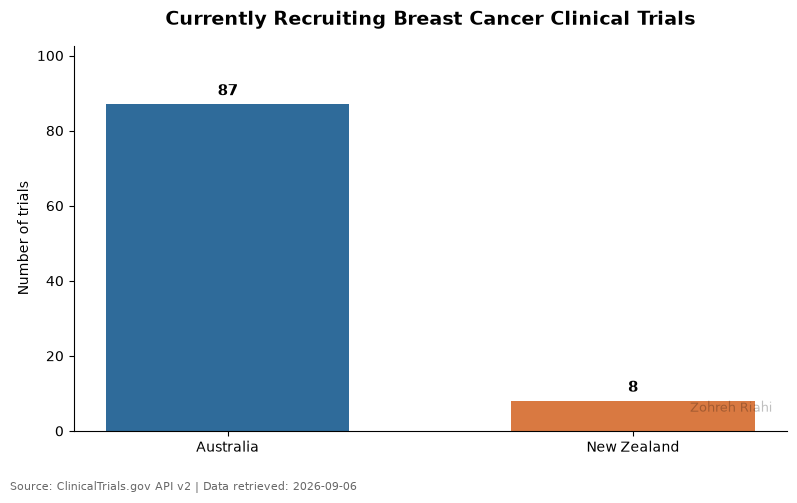

Saved: Figure1_Currently_Recruiting_Trials_Australia_New_Zealand_2026-09-06.png


In [43]:
import matplotlib.pyplot as plt

countries = country_summary.index.tolist()
trial_counts = country_summary[
    "Currently_Recruiting_Trials"
].tolist()

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    countries,
    trial_counts,
    color=["#2F6B9A", "#D97941"],
    width=0.6
)

ax.bar_label(
    bars,
    labels=[str(value) for value in trial_counts],
    padding=4,
    fontsize=11,
    fontweight="bold"
)

ax.set_title(
    "Currently Recruiting Breast Cancer Clinical Trials",
    fontsize=14,
    fontweight="bold",
    pad=15
)

ax.set_ylabel("Number of trials")
ax.set_ylim(0, max(trial_counts) * 1.18)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.text(
    0.98,
    0.05,
    "Zohreh Riahi",
    transform=ax.transAxes,
    ha="right",
    fontsize=9,
    alpha=0.25
)

fig.text(
    0.01,
    0.01,
    f"Source: ClinicalTrials.gov API v2 | Data retrieved: {retrieval_date}",
    fontsize=8,
    color="dimgray"
)

plt.tight_layout(rect=[0, 0.05, 1, 1])

figure1_filename = (
    f"Figure1_Currently_Recruiting_Trials_"
    f"Australia_New_Zealand_{retrieval_date}.png"
)

plt.savefig(
    figure1_filename,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", figure1_filename)

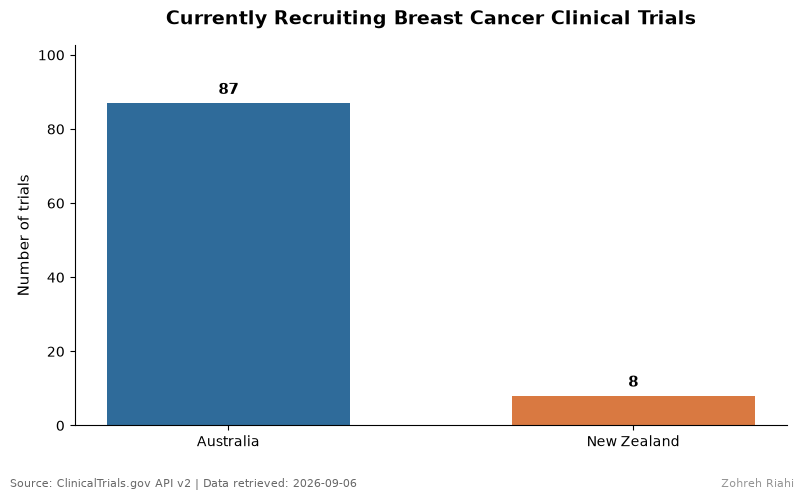

Saved: Figure1_Currently_Recruiting_Trials_Australia_New_Zealand_2026-09-06.png


In [44]:
import matplotlib.pyplot as plt

countries = country_summary.index.tolist()

trial_counts = country_summary[
    "Currently_Recruiting_Trials"
].tolist()

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    countries,
    trial_counts,
    color=["#2F6B9A", "#D97941"],
    width=0.6
)

ax.bar_label(
    bars,
    labels=[str(value) for value in trial_counts],
    padding=4,
    fontsize=11,
    fontweight="bold"
)

ax.set_title(
    "Currently Recruiting Breast Cancer Clinical Trials",
    fontsize=14,
    fontweight="bold",
    pad=15
)

ax.set_ylabel(
    "Number of trials",
    fontsize=11
)

ax.set_ylim(
    0,
    max(trial_counts) * 1.18
)

ax.tick_params(
    axis="both",
    labelsize=10
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.text(
    0.01,
    0.015,
    f"Source: ClinicalTrials.gov API v2 | Data retrieved: {retrieval_date}",
    fontsize=8,
    color="dimgray",
    ha="left"
)

fig.text(
    0.99,
    0.015,
    "Zohreh Riahi",
    fontsize=8,
    color="dimgray",
    alpha=0.7,
    ha="right"
)

plt.tight_layout(
    rect=[0, 0.06, 1, 1]
)

figure1_filename = (
    f"Figure1_Currently_Recruiting_Trials_"
    f"Australia_New_Zealand_{retrieval_date}.png"
)

plt.savefig(
    figure1_filename,
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print("Saved:", figure1_filename)

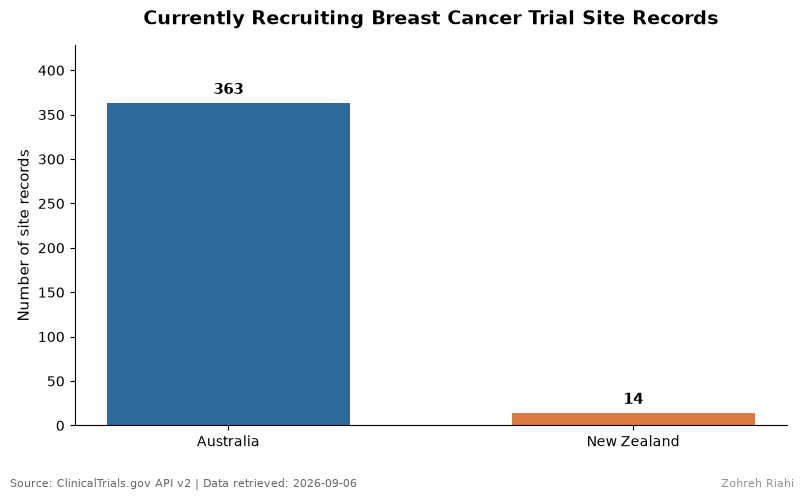

Saved: Figure2_Currently_Recruiting_Site_Records_Australia_New_Zealand_2026-09-06.png


In [45]:
site_counts = (
    current_recruiting_sites_df["Country"]
    .value_counts()
    .reindex(["Australia", "New Zealand"])
)

countries = site_counts.index.tolist()
values = site_counts.values.tolist()

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    countries,
    values,
    color=["#2F6B9A", "#D97941"],
    width=0.6
)

ax.bar_label(
    bars,
    labels=[str(value) for value in values],
    padding=4,
    fontsize=11,
    fontweight="bold"
)

ax.set_title(
    "Currently Recruiting Breast Cancer Trial Site Records",
    fontsize=14,
    fontweight="bold",
    pad=15
)

ax.set_ylabel(
    "Number of site records",
    fontsize=11
)

ax.set_ylim(
    0,
    max(values) * 1.18
)

ax.tick_params(
    axis="both",
    labelsize=10
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.text(
    0.01,
    0.015,
    f"Source: ClinicalTrials.gov API v2 | Data retrieved: {retrieval_date}",
    fontsize=8,
    color="dimgray",
    ha="left"
)

fig.text(
    0.99,
    0.015,
    "Zohreh Riahi",
    fontsize=8,
    color="dimgray",
    alpha=0.7,
    ha="right"
)

plt.tight_layout(
    rect=[0, 0.06, 1, 1]
)

figure2_filename = (
    f"Figure2_Currently_Recruiting_Site_Records_"
    f"Australia_New_Zealand_{retrieval_date}.png"
)

plt.savefig(
    figure2_filename,
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print("Saved:", figure2_filename)

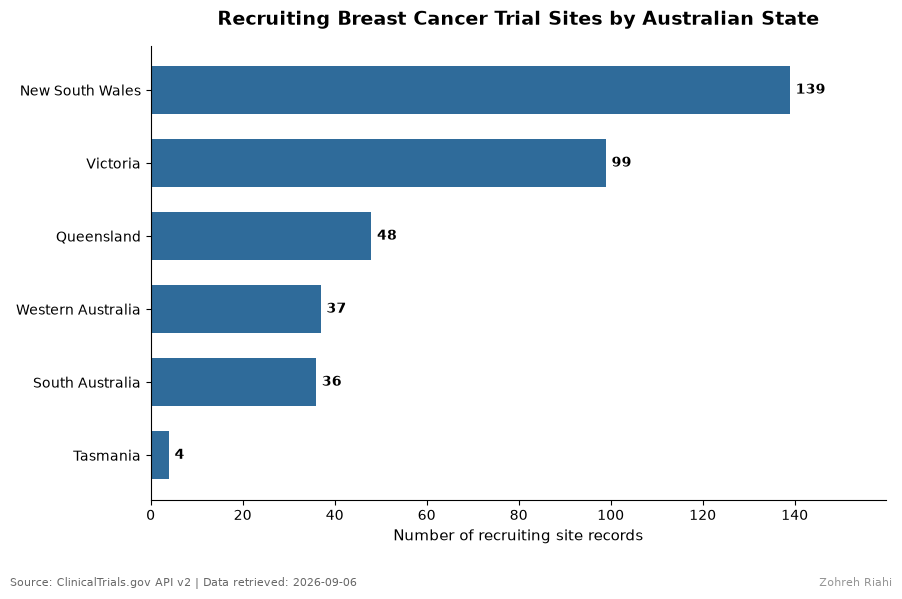

Saved: Figure3_Recruiting_Sites_by_Australian_State_2026-09-06.png


In [46]:
australia_state_counts = (
    current_recruiting_sites_df.loc[
        current_recruiting_sites_df["Country"].eq("Australia"),
        "State_Region"
    ]
    .value_counts()
    .sort_values()
)

fig, ax = plt.subplots(figsize=(9, 6))

bars = ax.barh(
    australia_state_counts.index,
    australia_state_counts.values,
    color="#2F6B9A",
    height=0.65
)

ax.bar_label(
    bars,
    labels=[
        str(value)
        for value in australia_state_counts.values
    ],
    padding=4,
    fontsize=10,
    fontweight="bold"
)

ax.set_title(
    "Recruiting Breast Cancer Trial Sites by Australian State",
    fontsize=14,
    fontweight="bold",
    pad=15
)

ax.set_xlabel(
    "Number of recruiting site records",
    fontsize=11
)

ax.set_xlim(
    0,
    australia_state_counts.max() * 1.15
)

ax.tick_params(
    axis="both",
    labelsize=10
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.text(
    0.01,
    0.015,
    f"Source: ClinicalTrials.gov API v2 | Data retrieved: {retrieval_date}",
    fontsize=8,
    color="dimgray",
    ha="left"
)

fig.text(
    0.99,
    0.015,
    "Zohreh Riahi",
    fontsize=8,
    color="dimgray",
    alpha=0.7,
    ha="right"
)

plt.tight_layout(
    rect=[0, 0.06, 1, 1]
)

figure3_filename = (
    f"Figure3_Recruiting_Sites_by_Australian_State_"
    f"{retrieval_date}.png"
)

plt.savefig(
    figure3_filename,
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print("Saved:", figure3_filename)

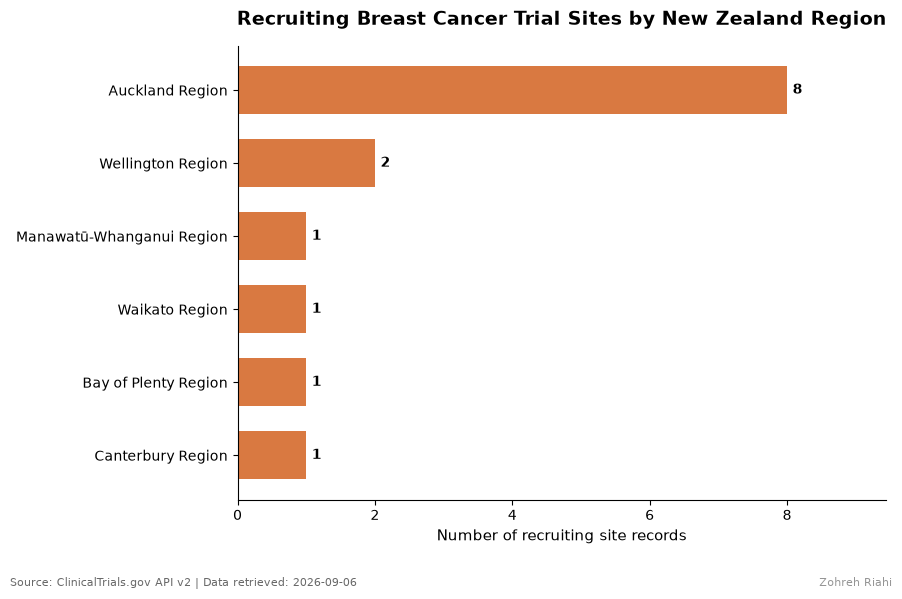

Saved: Figure4_Recruiting_Sites_by_New_Zealand_Region_2026-09-06.png


In [47]:
new_zealand_region_counts = (
    current_recruiting_sites_df.loc[
        current_recruiting_sites_df["Country"].eq("New Zealand"),
        "State_Region"
    ]
    .value_counts()
    .sort_values()
)

fig, ax = plt.subplots(figsize=(9, 6))

bars = ax.barh(
    new_zealand_region_counts.index,
    new_zealand_region_counts.values,
    color="#D97941",
    height=0.65
)

ax.bar_label(
    bars,
    labels=[
        str(value)
        for value in new_zealand_region_counts.values
    ],
    padding=4,
    fontsize=10,
    fontweight="bold"
)

ax.set_title(
    "Recruiting Breast Cancer Trial Sites by New Zealand Region",
    fontsize=14,
    fontweight="bold",
    pad=15
)

ax.set_xlabel(
    "Number of recruiting site records",
    fontsize=11
)

ax.set_xlim(
    0,
    new_zealand_region_counts.max() * 1.18
)

ax.tick_params(
    axis="both",
    labelsize=10
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.text(
    0.01,
    0.015,
    f"Source: ClinicalTrials.gov API v2 | Data retrieved: {retrieval_date}",
    fontsize=8,
    color="dimgray",
    ha="left"
)

fig.text(
    0.99,
    0.015,
    "Zohreh Riahi",
    fontsize=8,
    color="dimgray",
    alpha=0.7,
    ha="right"
)

plt.tight_layout(
    rect=[0, 0.06, 1, 1]
)

figure4_filename = (
    f"Figure4_Recruiting_Sites_by_New_Zealand_Region_"
    f"{retrieval_date}.png"
)

plt.savefig(
    figure4_filename,
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print("Saved:", figure4_filename)

In [48]:
phase_label_map = {
    "EARLY_PHASE1": "Early Phase 1",
    "PHASE1": "Phase 1",
    "PHASE1, PHASE2": "Phase 1/2",
    "PHASE2": "Phase 2",
    "PHASE2, PHASE3": "Phase 2/3",
    "PHASE3": "Phase 3",
    "NA": "Not Applicable"
}

phase_order = [
    "Early Phase 1",
    "Phase 1",
    "Phase 1/2",
    "Phase 2",
    "Phase 2/3",
    "Phase 3",
    "Not Applicable"
]

current_country_trial_df["Phase_Label"] = (
    current_country_trial_df["Phases"]
    .map(phase_label_map)
)

phase_counts_current = pd.crosstab(
    current_country_trial_df["Phase_Label"],
    current_country_trial_df["Country"]
).reindex(phase_order, fill_value=0)

phase_percent_current = (
    pd.crosstab(
        current_country_trial_df["Phase_Label"],
        current_country_trial_df["Country"],
        normalize="columns"
    )
    .mul(100)
    .reindex(phase_order, fill_value=0)
    .round(1)
)

phase_summary = pd.DataFrame({
    "Australia_Count":
        phase_counts_current["Australia"],
    "Australia_Percent":
        phase_percent_current["Australia"],
    "New_Zealand_Count":
        phase_counts_current["New Zealand"],
    "New_Zealand_Percent":
        phase_percent_current["New Zealand"]
})

phase_summary.to_csv(
    f"Table2_Phase_Distribution_Currently_Recruiting_"
    f"Trials_{retrieval_date}.csv"
)

print(phase_summary.to_string())

                Australia_Count  Australia_Percent  New_Zealand_Count  New_Zealand_Percent
Phase_Label                                                                               
Early Phase 1                 2                2.3                  0                  0.0
Phase 1                      23               26.4                  2                 25.0
Phase 1/2                    27               31.0                  0                  0.0
Phase 2                       6                6.9                  0                  0.0
Phase 2/3                     2                2.3                  1                 12.5
Phase 3                      23               26.4                  5                 62.5
Not Applicable                4                4.6                  0                  0.0


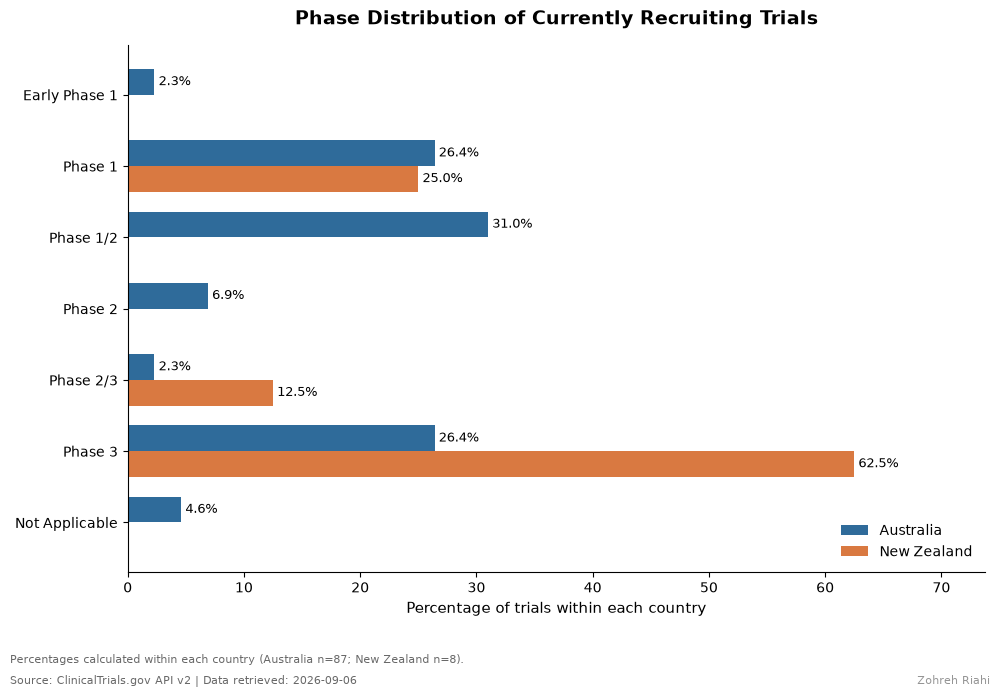

Saved: Figure5_Phase_Distribution_Currently_Recruiting_Trials_2026-09-06.png


In [49]:
import numpy as np

australia_phase_percent = (
    phase_summary["Australia_Percent"].values
)

new_zealand_phase_percent = (
    phase_summary["New_Zealand_Percent"].values
)

y_positions = np.arange(len(phase_order))
bar_height = 0.36

fig, ax = plt.subplots(figsize=(10, 7))

australia_bars = ax.barh(
    y_positions - bar_height / 2,
    australia_phase_percent,
    height=bar_height,
    label="Australia",
    color="#2F6B9A"
)

new_zealand_bars = ax.barh(
    y_positions + bar_height / 2,
    new_zealand_phase_percent,
    height=bar_height,
    label="New Zealand",
    color="#D97941"
)

australia_labels = [
    f"{value:.1f}%" if value > 0 else ""
    for value in australia_phase_percent
]

new_zealand_labels = [
    f"{value:.1f}%" if value > 0 else ""
    for value in new_zealand_phase_percent
]

ax.bar_label(
    australia_bars,
    labels=australia_labels,
    padding=3,
    fontsize=9
)

ax.bar_label(
    new_zealand_bars,
    labels=new_zealand_labels,
    padding=3,
    fontsize=9
)

ax.set_yticks(
    y_positions,
    labels=phase_order
)

ax.invert_yaxis()

ax.set_title(
    "Phase Distribution of Currently Recruiting Trials",
    fontsize=14,
    fontweight="bold",
    pad=15
)

ax.set_xlabel(
    "Percentage of trials within each country",
    fontsize=11
)

maximum_percentage = max(
    australia_phase_percent.max(),
    new_zealand_phase_percent.max()
)

ax.set_xlim(
    0,
    maximum_percentage * 1.18
)

ax.legend(
    frameon=False,
    loc="lower right"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.text(
    0.01,
    0.045,
    "Percentages calculated within each country "
    "(Australia n=87; New Zealand n=8).",
    fontsize=8,
    color="dimgray",
    ha="left"
)

fig.text(
    0.01,
    0.015,
    f"Source: ClinicalTrials.gov API v2 | Data retrieved: {retrieval_date}",
    fontsize=8,
    color="dimgray",
    ha="left"
)

fig.text(
    0.99,
    0.015,
    "Zohreh Riahi",
    fontsize=8,
    color="dimgray",
    alpha=0.7,
    ha="right"
)

plt.tight_layout(
    rect=[0, 0.09, 1, 1]
)

figure5_filename = (
    f"Figure5_Phase_Distribution_Currently_"
    f"Recruiting_Trials_{retrieval_date}.png"
)

plt.savefig(
    figure5_filename,
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print("Saved:", figure5_filename)

In [50]:
sponsor_counts_current = pd.crosstab(
    current_country_trial_df["Sponsor_Class"],
    current_country_trial_df["Country"]
)

sponsor_percent_current = (
    pd.crosstab(
        current_country_trial_df["Sponsor_Class"],
        current_country_trial_df["Country"],
        normalize="columns"
    )
    .mul(100)
    .round(1)
)

sponsor_order = ["INDUSTRY", "OTHER"]

sponsor_counts_current = (
    sponsor_counts_current
    .reindex(sponsor_order, fill_value=0)
)

sponsor_percent_current = (
    sponsor_percent_current
    .reindex(sponsor_order, fill_value=0)
)

sponsor_summary = pd.DataFrame({
    "Australia_Count":
        sponsor_counts_current["Australia"],
    "Australia_Percent":
        sponsor_percent_current["Australia"],
    "New_Zealand_Count":
        sponsor_counts_current["New Zealand"],
    "New_Zealand_Percent":
        sponsor_percent_current["New Zealand"]
})

sponsor_summary.index = [
    "Industry",
    "Other"
]

sponsor_summary.to_csv(
    f"Table3_Sponsor_Distribution_Currently_"
    f"Recruiting_Trials_{retrieval_date}.csv"
)

print(sponsor_summary.to_string())

          Australia_Count  Australia_Percent  New_Zealand_Count  New_Zealand_Percent
Industry               78               89.7                  7                 87.5
Other                   9               10.3                  1                 12.5


In [51]:
intervention_rows = []

for study in studies:
    protocol = study.get("protocolSection", {})

    identification = protocol.get(
        "identificationModule",
        {}
    )

    nct_id = identification.get("nctId")

    if nct_id not in current_trial_ids:
        continue

    interventions_module = protocol.get(
        "armsInterventionsModule",
        {}
    )

    interventions = interventions_module.get(
        "interventions",
        []
    )

    for intervention in interventions:
        intervention_rows.append({
            "NCT_ID": nct_id,
            "Intervention_Type": intervention.get("type"),
            "Intervention_Name": intervention.get("name")
        })

interventions_df = pd.DataFrame(intervention_rows)

trial_intervention_types_df = (
    interventions_df[
        ["NCT_ID", "Intervention_Type"]
    ]
    .drop_duplicates()
)

trial_country_keys = (
    current_country_trial_df[
        ["NCT_ID", "Country"]
    ]
    .drop_duplicates()
)

country_intervention_df = trial_country_keys.merge(
    trial_intervention_types_df,
    on="NCT_ID",
    how="left"
)

print(
    "Total intervention records:",
    len(interventions_df)
)

print(
    "Unique trial–intervention type combinations:",
    len(trial_intervention_types_df)
)

print("\nIntervention types:")
print(
    trial_intervention_types_df[
        "Intervention_Type"
    ]
    .value_counts(dropna=False)
    .to_string()
)

Total intervention records: 319
Unique trial–intervention type combinations: 98

Intervention types:
Intervention_Type
DRUG               78
BIOLOGICAL         10
RADIATION           4
DIAGNOSTIC_TEST     3
OTHER               2
PROCEDURE           1


In [52]:
intervention_type_order = [
    "DRUG",
    "BIOLOGICAL",
    "RADIATION",
    "DIAGNOSTIC_TEST",
    "OTHER",
    "PROCEDURE"
]

intervention_counts_country = pd.crosstab(
    country_intervention_df["Intervention_Type"],
    country_intervention_df["Country"]
).reindex(
    intervention_type_order,
    fill_value=0
)

country_trial_totals = pd.Series({
    "Australia": 87,
    "New Zealand": 8
})

intervention_percent_country = (
    intervention_counts_country
    .div(country_trial_totals, axis="columns")
    .mul(100)
    .round(1)
)

intervention_summary = pd.DataFrame({
    "Australia_Count":
        intervention_counts_country["Australia"],
    "Australia_Percent":
        intervention_percent_country["Australia"],
    "New_Zealand_Count":
        intervention_counts_country["New Zealand"],
    "New_Zealand_Percent":
        intervention_percent_country["New Zealand"]
})

intervention_summary.index = [
    "Drug",
    "Biological",
    "Radiation",
    "Diagnostic test",
    "Other",
    "Procedure"
]

intervention_summary.to_csv(
    f"Table4_Intervention_Type_Distribution_"
    f"{retrieval_date}.csv"
)

print(intervention_summary.to_string())

print(
    "\nNote: Percentages may total more than 100% "
    "because trials can include multiple intervention types."
)

                 Australia_Count  Australia_Percent  New_Zealand_Count  New_Zealand_Percent
Drug                          77               88.5                  8                100.0
Biological                    10               11.5                  2                 25.0
Radiation                      4                4.6                  0                  0.0
Diagnostic test                3                3.4                  1                 12.5
Other                          2                2.3                  0                  0.0
Procedure                      1                1.1                  0                  0.0

Note: Percentages may total more than 100% because trials can include multiple intervention types.


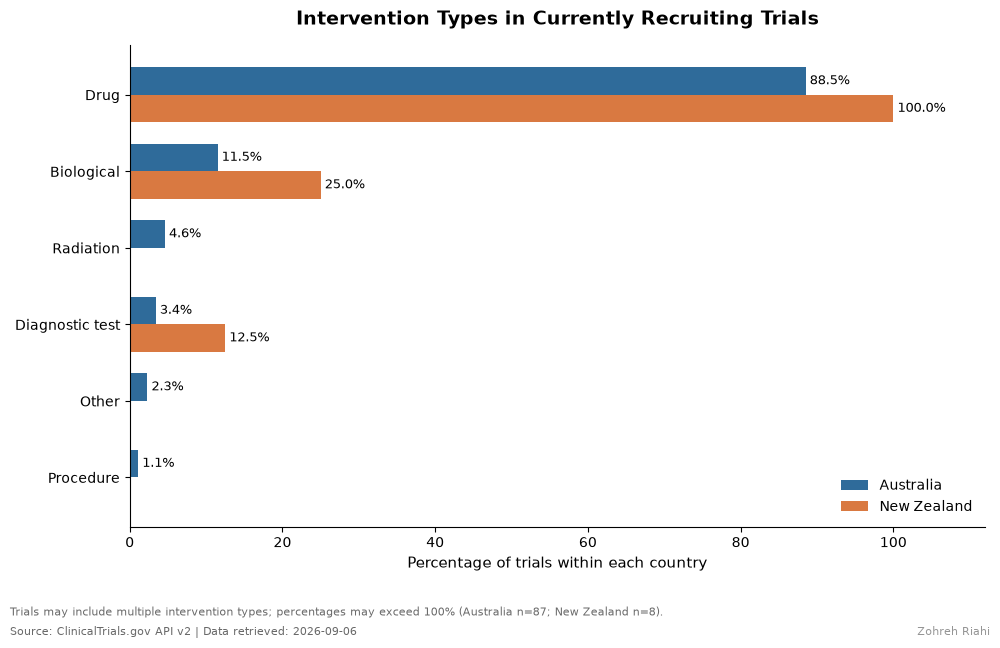

Saved: Figure6_Intervention_Types_Currently_Recruiting_Trials_2026-09-06.png


In [53]:
intervention_labels = intervention_summary.index.tolist()

australia_intervention_percent = (
    intervention_summary["Australia_Percent"].values
)

new_zealand_intervention_percent = (
    intervention_summary["New_Zealand_Percent"].values
)

y_positions = np.arange(len(intervention_labels))
bar_height = 0.36

fig, ax = plt.subplots(figsize=(10, 6.5))

australia_bars = ax.barh(
    y_positions - bar_height / 2,
    australia_intervention_percent,
    height=bar_height,
    label="Australia",
    color="#2F6B9A"
)

new_zealand_bars = ax.barh(
    y_positions + bar_height / 2,
    new_zealand_intervention_percent,
    height=bar_height,
    label="New Zealand",
    color="#D97941"
)

australia_labels = [
    f"{value:.1f}%" if value > 0 else ""
    for value in australia_intervention_percent
]

new_zealand_labels = [
    f"{value:.1f}%" if value > 0 else ""
    for value in new_zealand_intervention_percent
]

ax.bar_label(
    australia_bars,
    labels=australia_labels,
    padding=3,
    fontsize=9
)

ax.bar_label(
    new_zealand_bars,
    labels=new_zealand_labels,
    padding=3,
    fontsize=9
)

ax.set_yticks(
    y_positions,
    labels=intervention_labels
)

ax.invert_yaxis()

ax.set_title(
    "Intervention Types in Currently Recruiting Trials",
    fontsize=14,
    fontweight="bold",
    pad=15
)

ax.set_xlabel(
    "Percentage of trials within each country",
    fontsize=11
)

ax.set_xlim(0, 112)

ax.legend(
    frameon=False,
    loc="lower right"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.text(
    0.01,
    0.045,
    "Trials may include multiple intervention types; percentages may exceed 100% "
    "(Australia n=87; New Zealand n=8).",
    fontsize=8,
    color="dimgray",
    ha="left"
)

fig.text(
    0.01,
    0.015,
    f"Source: ClinicalTrials.gov API v2 | Data retrieved: {retrieval_date}",
    fontsize=8,
    color="dimgray",
    ha="left"
)

fig.text(
    0.99,
    0.015,
    "Zohreh Riahi",
    fontsize=8,
    color="dimgray",
    alpha=0.7,
    ha="right"
)

plt.tight_layout(
    rect=[0, 0.09, 1, 1]
)

figure6_filename = (
    f"Figure6_Intervention_Types_Currently_"
    f"Recruiting_Trials_{retrieval_date}.png"
)

plt.savefig(
    figure6_filename,
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print("Saved:", figure6_filename)

In [54]:
#بررسی می‌کنیم کدام داروها یا مداخلات در بیشترین تعداد کارآزمایی‌ها استفاده شده‌اند. ابتدا نام‌های ثبت‌شده را بدون تغییر بررسی می‌کنیم
unique_trial_interventions = (
    interventions_df
    .dropna(subset=["Intervention_Name"])
    .copy()
)

unique_trial_interventions["Intervention_Name"] = (
    unique_trial_interventions["Intervention_Name"]
    .str.strip()
)

unique_trial_interventions = (
    unique_trial_interventions[
        unique_trial_interventions[
            "Intervention_Name"
        ].ne("")
    ]
    .drop_duplicates(
        subset=["NCT_ID", "Intervention_Name"]
    )
)

top_interventions = (
    unique_trial_interventions
    .groupby("Intervention_Name")["NCT_ID"]
    .nunique()
    .sort_values(ascending=False)
    .head(25)
)

print(
    "Top intervention names by number of trials:"
)

print(top_interventions.to_string())

Top intervention names by number of trials:
Intervention_Name
Fulvestrant                16
Letrozole                  10
Abemaciclib                10
Ribociclib                 10
Palbociclib                 9
Capecitabine                9
Pembrolizumab               7
Paclitaxel                  6
Carboplatin                 6
Nab-paclitaxel              5
Gemcitabine                 5
Exemestane                  4
Inavolisib                  4
Placebo                     4
Sacituzumab tirumotecan     4
Giredestrant                4
BGB-43395                   3
Anastrozole                 3
Everolimus                  3
Pumitamig                   3
Trastuzumab                 3
Palazestrant                3
Elacestrant                 2
Camizestrant                2
Docetaxel                   2


In [56]:
non_placebo_interventions = (
    unique_trial_interventions[
        ~unique_trial_interventions[
            "Intervention_Name"
        ]
        .str.casefold()
        .eq("placebo")
    ]
    .copy()
)

top_10_interventions = (
    non_placebo_interventions
    .groupby("Intervention_Name")["NCT_ID"]
    .nunique()
    .sort_values(ascending=False)
    .head(10)
    .reset_index(name="Number_of_Trials")
)

top_10_interventions["Percent_of_88_Trials"] = (
    top_10_interventions["Number_of_Trials"]
    .div(88)
    .mul(100)
    .round(1)
)

top_10_interventions.to_csv(
    f"Table5_Top_10_Non_Placebo_Interventions_"
    f"{retrieval_date}.csv",
    index=False
)

print(top_10_interventions.to_string(index=False))

Intervention_Name  Number_of_Trials  Percent_of_88_Trials
      Fulvestrant                16                  18.2
      Abemaciclib                10                  11.4
        Letrozole                10                  11.4
       Ribociclib                10                  11.4
      Palbociclib                 9                  10.2
     Capecitabine                 9                  10.2
    Pembrolizumab                 7                   8.0
      Carboplatin                 6                   6.8
       Paclitaxel                 6                   6.8
      Gemcitabine                 5                   5.7


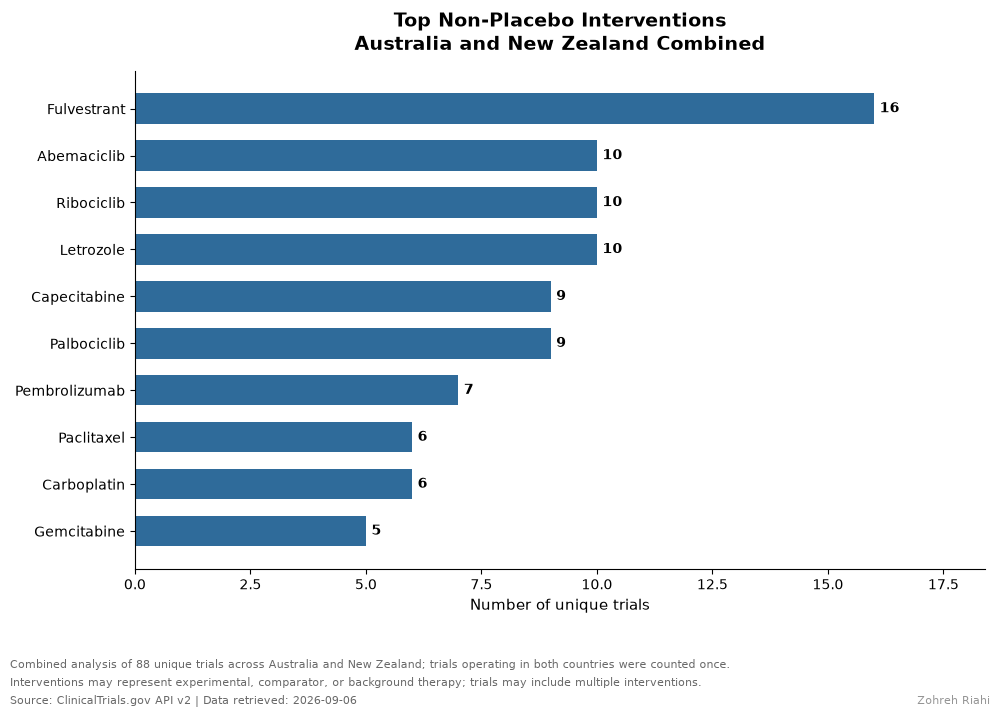

Saved: Figure7_Top_Non_Placebo_Interventions_Australia_New_Zealand_Combined_2026-09-06.png


In [59]:
plot_interventions = (
    top_10_interventions
    .sort_values("Number_of_Trials")
)

fig, ax = plt.subplots(figsize=(10, 7.2))

bars = ax.barh(
    plot_interventions["Intervention_Name"],
    plot_interventions["Number_of_Trials"],
    color="#2F6B9A",
    height=0.65
)

ax.bar_label(
    bars,
    labels=[
        str(value)
        for value in plot_interventions[
            "Number_of_Trials"
        ]
    ],
    padding=4,
    fontsize=10,
    fontweight="bold"
)

ax.set_title(
    "Top Non-Placebo Interventions\n"
    "Australia and New Zealand Combined",
    fontsize=14,
    fontweight="bold",
    pad=15
)

ax.set_xlabel(
    "Number of unique trials",
    fontsize=11
)

ax.set_xlim(
    0,
    plot_interventions[
        "Number_of_Trials"
    ].max() * 1.15
)

ax.tick_params(
    axis="both",
    labelsize=10
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.text(
    0.01,
    0.065,
    "Combined analysis of 88 unique trials across Australia and New Zealand; "
    "trials operating in both countries were counted once.",
    fontsize=8,
    color="dimgray",
    ha="left"
)

fig.text(
    0.01,
    0.04,
    "Interventions may represent experimental, comparator, or background therapy; "
    "trials may include multiple interventions.",
    fontsize=8,
    color="dimgray",
    ha="left"
)

fig.text(
    0.01,
    0.015,
    f"Source: ClinicalTrials.gov API v2 | Data retrieved: {retrieval_date}",
    fontsize=8,
    color="dimgray",
    ha="left"
)

fig.text(
    0.99,
    0.015,
    "Zohreh Riahi",
    fontsize=8,
    color="dimgray",
    alpha=0.7,
    ha="right"
)

plt.tight_layout(
    rect=[0, 0.12, 1, 1]
)

figure7_filename = (
    f"Figure7_Top_Non_Placebo_Interventions_"
    f"Australia_New_Zealand_Combined_"
    f"{retrieval_date}.png"
)

plt.savefig(
    figure7_filename,
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print("Saved:", figure7_filename)

In [60]:
#تعدیل مقایسه براساس جمعیت
population_adjusted_summary = pd.DataFrame({
    "Country": [
        "Australia",
        "New Zealand"
    ],
    "Population_30_June_2025": [
        27614411,
        5324700
    ],
    "Currently_Recruiting_Trials": [
        87,
        8
    ],
    "Recruiting_Site_Records": [
        363,
        14
    ]
})

population_adjusted_summary[
    "Trials_per_Million"
] = (
    population_adjusted_summary[
        "Currently_Recruiting_Trials"
    ]
    / population_adjusted_summary[
        "Population_30_June_2025"
    ]
    * 1_000_000
).round(2)

population_adjusted_summary[
    "Site_Records_per_Million"
] = (
    population_adjusted_summary[
        "Recruiting_Site_Records"
    ]
    / population_adjusted_summary[
        "Population_30_June_2025"
    ]
    * 1_000_000
).round(2)

australia_trial_rate = (
    population_adjusted_summary.loc[
        population_adjusted_summary["Country"].eq("Australia"),
        "Trials_per_Million"
    ].iloc[0]
)

new_zealand_trial_rate = (
    population_adjusted_summary.loc[
        population_adjusted_summary["Country"].eq("New Zealand"),
        "Trials_per_Million"
    ].iloc[0]
)

australia_site_rate = (
    population_adjusted_summary.loc[
        population_adjusted_summary["Country"].eq("Australia"),
        "Site_Records_per_Million"
    ].iloc[0]
)

new_zealand_site_rate = (
    population_adjusted_summary.loc[
        population_adjusted_summary["Country"].eq("New Zealand"),
        "Site_Records_per_Million"
    ].iloc[0]
)

print(population_adjusted_summary.to_string(index=False))

print(
    "\nAustralia-to-New Zealand trial rate ratio:",
    round(
        australia_trial_rate / new_zealand_trial_rate,
        2
    )
)

print(
    "Australia-to-New Zealand site rate ratio:",
    round(
        australia_site_rate / new_zealand_site_rate,
        2
    )
)

population_adjusted_summary.to_csv(
    f"Table6_Population_Adjusted_Recruitment_"
    f"Comparison_{retrieval_date}.csv",
    index=False
)

    Country  Population_30_June_2025  Currently_Recruiting_Trials  Recruiting_Site_Records  Trials_per_Million  Site_Records_per_Million
  Australia                 27614411                           87                      363                3.15                     13.15
New Zealand                  5324700                            8                       14                1.50                      2.63

Australia-to-New Zealand trial rate ratio: 2.1
Australia-to-New Zealand site rate ratio: 5.0


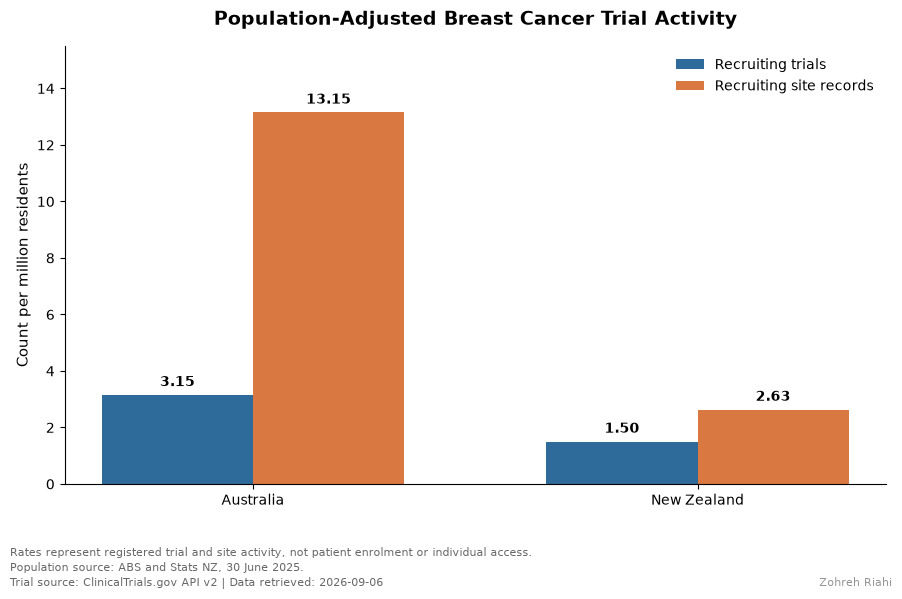

Saved: Figure8_Population_Adjusted_Trial_Activity_2026-09-06.png


In [61]:
countries = population_adjusted_summary[
    "Country"
].tolist()

trial_rates = population_adjusted_summary[
    "Trials_per_Million"
].tolist()

site_rates = population_adjusted_summary[
    "Site_Records_per_Million"
].tolist()

x_positions = np.arange(len(countries))
bar_width = 0.34

fig, ax = plt.subplots(figsize=(9, 6))

trial_bars = ax.bar(
    x_positions - bar_width / 2,
    trial_rates,
    width=bar_width,
    label="Recruiting trials",
    color="#2F6B9A"
)

site_bars = ax.bar(
    x_positions + bar_width / 2,
    site_rates,
    width=bar_width,
    label="Recruiting site records",
    color="#D97941"
)

ax.bar_label(
    trial_bars,
    labels=[
        f"{value:.2f}"
        for value in trial_rates
    ],
    padding=4,
    fontsize=10,
    fontweight="bold"
)

ax.bar_label(
    site_bars,
    labels=[
        f"{value:.2f}"
        for value in site_rates
    ],
    padding=4,
    fontsize=10,
    fontweight="bold"
)

ax.set_xticks(
    x_positions,
    labels=countries
)

ax.set_title(
    "Population-Adjusted Breast Cancer Trial Activity",
    fontsize=14,
    fontweight="bold",
    pad=15
)

ax.set_ylabel(
    "Count per million residents",
    fontsize=11
)

ax.set_ylim(
    0,
    max(site_rates) * 1.18
)

ax.legend(
    frameon=False,
    loc="upper right"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.text(
    0.01,
    0.065,
    "Rates represent registered trial and site activity, not patient enrolment "
    "or individual access.",
    fontsize=8,
    color="dimgray",
    ha="left"
)

fig.text(
    0.01,
    0.04,
    "Population source: ABS and Stats NZ, 30 June 2025.",
    fontsize=8,
    color="dimgray",
    ha="left"
)

fig.text(
    0.01,
    0.015,
    f"Trial source: ClinicalTrials.gov API v2 | Data retrieved: {retrieval_date}",
    fontsize=8,
    color="dimgray",
    ha="left"
)

fig.text(
    0.99,
    0.015,
    "Zohreh Riahi",
    fontsize=8,
    color="dimgray",
    alpha=0.7,
    ha="right"
)

plt.tight_layout(
    rect=[0, 0.12, 1, 1]
)

figure8_filename = (
    f"Figure8_Population_Adjusted_Trial_Activity_"
    f"{retrieval_date}.png"
)

plt.savefig(
    figure8_filename,
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print("Saved:", figure8_filename)

In [62]:
top_lead_sponsors = (
    current_trials_df
    .groupby(
        ["Lead_Sponsor", "Sponsor_Class"]
    )["NCT_ID"]
    .nunique()
    .sort_values(ascending=False)
    .head(20)
)

print(
    "Top lead sponsors by number of unique trials:"
)

print(top_lead_sponsors.to_string())

Top lead sponsors by number of unique trials:
Lead_Sponsor                   Sponsor_Class
AstraZeneca                    INDUSTRY         7
Hoffmann-La Roche              INDUSTRY         7
Merck Sharp & Dohme LLC        INDUSTRY         5
BeOne Medicines                INDUSTRY         4
Eli Lilly and Company          INDUSTRY         3
Bristol-Myers Squibb           INDUSTRY         3
Olema Pharmaceuticals, Inc.    INDUSTRY         3
Pfizer                         INDUSTRY         3
Gilead Sciences                INDUSTRY         2
Relay Therapeutics, Inc.       INDUSTRY         2
Myeloid Therapeutics           INDUSTRY         2
BioNTech SE                    INDUSTRY         2
St Vincent's Hospital, Sydney  OTHER            2
Daiichi Sankyo                 INDUSTRY         2
Novartis Pharmaceuticals       INDUSTRY         2
Eikon Therapeutics             INDUSTRY         1
Atridia Pty Ltd.               INDUSTRY         1
Alpha-9 Oncology USA Inc.      INDUSTRY         1
Bayer    

In [63]:
top_10_sponsors = (
    current_trials_df
    .groupby(
        ["Lead_Sponsor", "Sponsor_Class"]
    )["NCT_ID"]
    .nunique()
    .sort_values(ascending=False)
    .head(10)
    .reset_index(
        name="Number_of_Trials"
    )
)

top_10_sponsors[
    "Percent_of_88_Trials"
] = (
    top_10_sponsors[
        "Number_of_Trials"
    ]
    .div(88)
    .mul(100)
    .round(1)
)

top_10_sponsors.to_csv(
    f"Table7_Top_10_Lead_Sponsors_"
    f"{retrieval_date}.csv",
    index=False
)

print(top_10_sponsors.to_string(index=False))

               Lead_Sponsor Sponsor_Class  Number_of_Trials  Percent_of_88_Trials
                AstraZeneca      INDUSTRY                 7                   8.0
          Hoffmann-La Roche      INDUSTRY                 7                   8.0
    Merck Sharp & Dohme LLC      INDUSTRY                 5                   5.7
            BeOne Medicines      INDUSTRY                 4                   4.5
      Eli Lilly and Company      INDUSTRY                 3                   3.4
       Bristol-Myers Squibb      INDUSTRY                 3                   3.4
Olema Pharmaceuticals, Inc.      INDUSTRY                 3                   3.4
                     Pfizer      INDUSTRY                 3                   3.4
            Gilead Sciences      INDUSTRY                 2                   2.3
   Relay Therapeutics, Inc.      INDUSTRY                 2                   2.3


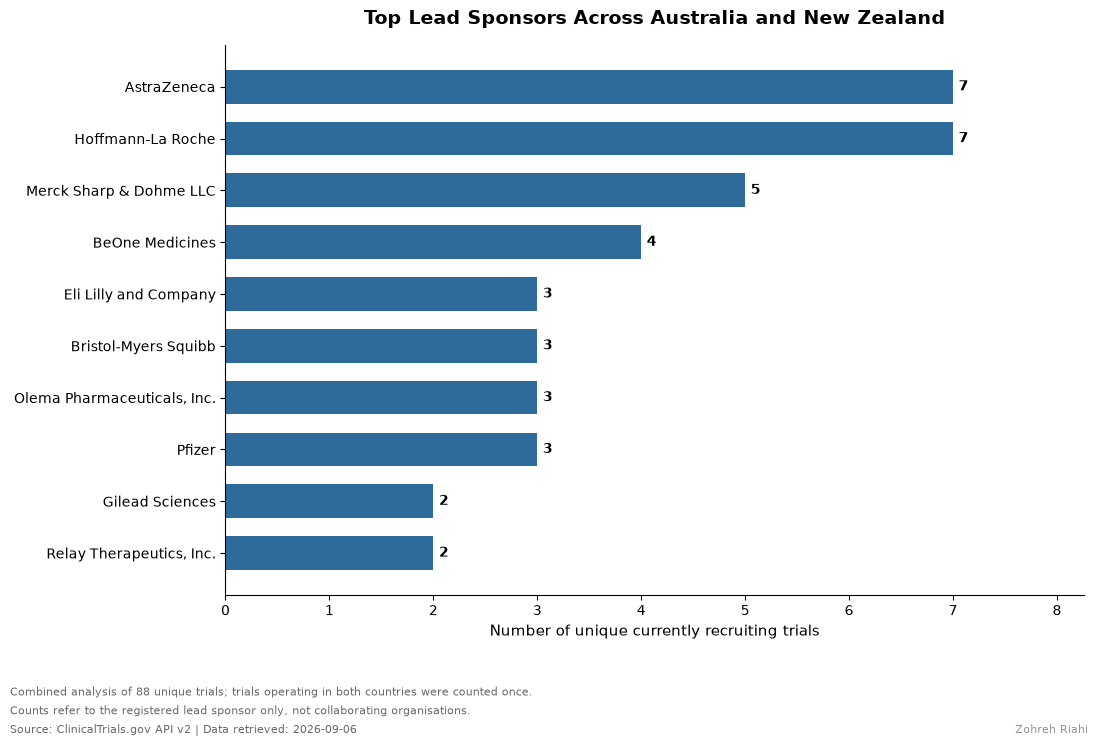

Saved: Figure9_Top_Lead_Sponsors_Australia_New_Zealand_2026-09-06.png


In [64]:
plot_sponsors = (
    top_10_sponsors
    .sort_values("Number_of_Trials")
)

fig, ax = plt.subplots(figsize=(11, 7.5))

bars = ax.barh(
    plot_sponsors["Lead_Sponsor"],
    plot_sponsors["Number_of_Trials"],
    color="#2F6B9A",
    height=0.65
)

ax.bar_label(
    bars,
    labels=[
        str(value)
        for value in plot_sponsors[
            "Number_of_Trials"
        ]
    ],
    padding=4,
    fontsize=10,
    fontweight="bold"
)

ax.set_title(
    "Top Lead Sponsors Across Australia and New Zealand",
    fontsize=14,
    fontweight="bold",
    pad=15
)

ax.set_xlabel(
    "Number of unique currently recruiting trials",
    fontsize=11
)

ax.set_xlim(
    0,
    plot_sponsors[
        "Number_of_Trials"
    ].max() * 1.18
)

ax.tick_params(
    axis="both",
    labelsize=10
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.text(
    0.01,
    0.065,
    "Combined analysis of 88 unique trials; trials operating in both countries "
    "were counted once.",
    fontsize=8,
    color="dimgray",
    ha="left"
)

fig.text(
    0.01,
    0.04,
    "Counts refer to the registered lead sponsor only, not collaborating organisations.",
    fontsize=8,
    color="dimgray",
    ha="left"
)

fig.text(
    0.01,
    0.015,
    f"Source: ClinicalTrials.gov API v2 | Data retrieved: {retrieval_date}",
    fontsize=8,
    color="dimgray",
    ha="left"
)

fig.text(
    0.99,
    0.015,
    "Zohreh Riahi",
    fontsize=8,
    color="dimgray",
    alpha=0.7,
    ha="right"
)

plt.tight_layout(
    rect=[0, 0.12, 1, 1]
)

figure9_filename = (
    f"Figure9_Top_Lead_Sponsors_Australia_"
    f"New_Zealand_{retrieval_date}.png"
)

plt.savefig(
    figure9_filename,
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print("Saved:", figure9_filename)

In [65]:
selection_flow = pd.DataFrame({
    "Stage": [
        "Initial API search results",
        "Confirmed Australia or New Zealand locations",
        "Overall status Recruiting or Not Yet Recruiting",
        "At least one recruiting or upcoming regional site",
        "Interventional trials only",
        "At least one currently recruiting regional site"
    ],
    "Number_of_Studies": [
        500,
        499,
        113,
        97,
        91,
        88
    ],
    "Excluded_at_Stage": [
        0,
        1,
        386,
        16,
        6,
        3
    ],
    "Reason": [
        "Breast cancer studies returned by the API location search",
        "Exact country validation using registered location records",
        "Excluded completed, terminated, withdrawn, unknown, and other statuses",
        "Confirmed a site-level status of Recruiting or Not Yet Recruiting",
        "Excluded six observational studies",
        "Excluded trials with only Not Yet Recruiting regional sites"
    ]
})

selection_flow.to_csv(
    f"Table8_Study_Selection_Flow_{retrieval_date}.csv",
    index=False
)

print(selection_flow.to_string(index=False))

                                            Stage  Number_of_Studies  Excluded_at_Stage                                                                 Reason
                       Initial API search results                500                  0              Breast cancer studies returned by the API location search
     Confirmed Australia or New Zealand locations                499                  1             Exact country validation using registered location records
  Overall status Recruiting or Not Yet Recruiting                113                386 Excluded completed, terminated, withdrawn, unknown, and other statuses
At least one recruiting or upcoming regional site                 97                 16      Confirmed a site-level status of Recruiting or Not Yet Recruiting
                       Interventional trials only                 91                  6                                     Excluded six observational studies
  At least one currently recruiting regional s

In [66]:
import glob
import os

data_files = sorted(
    glob.glob("Breast_Cancer*.csv")
)

table_files = sorted(
    glob.glob("Table*.csv")
)

figure_files = sorted(
    glob.glob("Figure*.png")
)

print("DATA FILES:", len(data_files))

for file in data_files:
    size_kb = os.path.getsize(file) / 1024
    print(f"- {file} ({size_kb:.1f} KB)")

print("\nTABLE FILES:", len(table_files))

for file in table_files:
    size_kb = os.path.getsize(file) / 1024
    print(f"- {file} ({size_kb:.1f} KB)")

print("\nFIGURE FILES:", len(figure_files))

for file in figure_files:
    size_kb = os.path.getsize(file) / 1024
    print(f"- {file} ({size_kb:.1f} KB)")

DATA FILES: 4
- Breast_Cancer_Currently_Recruiting_Sites_Aus_NZ_2026-09-06.csv (89.2 KB)
- Breast_Cancer_Currently_Recruiting_Trials_Aus_NZ_2026-09-06.csv (33.8 KB)
- Breast_Cancer_Open_Interventional_Trials_Aus_NZ.csv (31.9 KB)
- Breast_Cancer_Open_Trial_Sites_Aus_NZ.csv (92.3 KB)

TABLE FILES: 8
- Table1_Country_Recruitment_Summary_2026-09-06.csv (0.2 KB)
- Table2_Phase_Distribution_Currently_Recruiting_Trials_2026-09-06.csv (0.3 KB)
- Table3_Sponsor_Distribution_Currently_Recruiting_Trials_2026-09-06.csv (0.1 KB)
- Table4_Intervention_Type_Distribution_2026-09-06.csv (0.2 KB)
- Table5_Top_10_Non_Placebo_Interventions_2026-09-06.csv (0.2 KB)
- Table6_Population_Adjusted_Recruitment_Comparison_2026-09-06.csv (0.2 KB)
- Table7_Top_10_Lead_Sponsors_2026-09-06.csv (0.4 KB)
- Table8_Study_Selection_Flow_2026-09-06.csv (0.7 KB)

FIGURE FILES: 10
- Figure1_Currently_Recruiting_Trials_Australia_New_Zealand_2026-09-06.png (75.1 KB)
- Figure2_Currently_Recruiting_Site_Records_Australia_New_Zea

In [67]:
import pandas as pd

# Load the currently recruiting trials dataset
file_name = "Breast_Cancer_Currently_Recruiting_Trials_Aus_NZ_2026-09-06.csv"
trials = pd.read_csv(file_name)

country_columns = {
    "Australia": "Australia_Currently_Recruiting_Sites",
    "New Zealand": "New_Zealand_Currently_Recruiting_Sites"
}

records = []

# Convert intervention lists into one intervention per row
for _, row in trials.iterrows():

    intervention_names = str(row["Interventions"]).split(";")

    for intervention in intervention_names:

        intervention = intervention.strip()

        if not intervention:
            continue

        # Exclude placebo regardless of capitalisation
        if intervention.casefold() == "placebo":
            continue

        for country, site_column in country_columns.items():

            if pd.to_numeric(row[site_column], errors="coerce") > 0:

                records.append({
                    "NCT_ID": row["NCT_ID"],
                    "Country": country,
                    "Intervention_Raw": intervention,
                    "Intervention_Key": intervention.casefold()
                })

intervention_long = pd.DataFrame(records)

# Prevent duplicate counting within the same trial and country
intervention_long = intervention_long.drop_duplicates(
    subset=["NCT_ID", "Country", "Intervention_Key"]
)

# Select the most common spelling as the display name
label_map = (
    intervention_long
    .groupby(["Intervention_Key", "Intervention_Raw"])
    .size()
    .reset_index(name="Frequency")
    .sort_values(
        ["Intervention_Key", "Frequency", "Intervention_Raw"],
        ascending=[True, False, True]
    )
    .drop_duplicates("Intervention_Key")
    .set_index("Intervention_Key")["Intervention_Raw"]
)

intervention_long["Intervention"] = (
    intervention_long["Intervention_Key"].map(label_map)
)

# Count unique trials for every intervention within each country
country_intervention_counts = (
    intervention_long
    .groupby(["Country", "Intervention_Key", "Intervention"])
    ["NCT_ID"]
    .nunique()
    .reset_index(name="Trial_Count")
)

country_denominators = {
    "Australia": 87,
    "New Zealand": 8
}

country_intervention_counts["Country_Total_Trials"] = (
    country_intervention_counts["Country"].map(country_denominators)
)

country_intervention_counts["Percent_of_Country_Trials"] = (
    country_intervention_counts["Trial_Count"]
    / country_intervention_counts["Country_Total_Trials"]
    * 100
).round(1)

# Display the leading interventions in each country
for country in ["Australia", "New Zealand"]:

    print(f"\nTop interventions — {country}")

    display(
        country_intervention_counts[
            country_intervention_counts["Country"] == country
        ]
        .sort_values(
            ["Trial_Count", "Intervention"],
            ascending=[False, True]
        )
        .head(15)
        [["Intervention", "Trial_Count", "Percent_of_Country_Trials"]]
        .reset_index(drop=True)
    )


Top interventions — Australia


,Intervention,Trial_Count,Percent_of_Country_Trials
0,Fulvestrant,16,18.4
1,Ribociclib,11,12.6
2,Abemaciclib,10,11.5
3,Letrozole,10,11.5
4,Capecitabine,9,10.3
5,Palbociclib,9,10.3
6,Pembrolizumab,9,10.3
7,Carboplatin,7,8.0
8,Nab-paclitaxel,6,6.9
9,Paclitaxel,6,6.9



Top interventions — New Zealand


,Intervention,Trial_Count,Percent_of_Country_Trials
0,Fulvestrant,3,37.5
1,Capecitabine,2,25.0
2,Carboplatin,2,25.0
3,Paclitaxel,2,25.0
4,Pembrolizumab,2,25.0
5,Rescue Medication,2,25.0
6,Sacituzumab tirumotecan,2,25.0
7,Abemaciclib,1,12.5
8,Alpelisib,1,12.5
9,Anti-Diarrheal Agent,1,12.5


In [68]:
import pandas as pd

# Load the currently recruiting trials dataset
file_name = "Breast_Cancer_Currently_Recruiting_Trials_Aus_NZ_2026-09-06.csv"
trials = pd.read_csv(file_name)

country_columns = {
    "Australia": "Australia_Currently_Recruiting_Sites",
    "New Zealand": "New_Zealand_Currently_Recruiting_Sites"
}

records = []

# Convert intervention lists into one intervention per row
for _, row in trials.iterrows():

    intervention_names = str(row["Interventions"]).split(";")

    for intervention in intervention_names:

        intervention = intervention.strip()

        if not intervention:
            continue

        # Exclude placebo regardless of capitalisation
        if intervention.casefold() == "placebo":
            continue

        for country, site_column in country_columns.items():

            if pd.to_numeric(row[site_column], errors="coerce") > 0:

                records.append({
                    "NCT_ID": row["NCT_ID"],
                    "Country": country,
                    "Intervention_Raw": intervention,
                    "Intervention_Key": intervention.casefold()
                })

intervention_long = pd.DataFrame(records)

# Prevent duplicate counting within the same trial and country
intervention_long = intervention_long.drop_duplicates(
    subset=["NCT_ID", "Country", "Intervention_Key"]
)

# Select the most common spelling as the display name
label_map = (
    intervention_long
    .groupby(["Intervention_Key", "Intervention_Raw"])
    .size()
    .reset_index(name="Frequency")
    .sort_values(
        ["Intervention_Key", "Frequency", "Intervention_Raw"],
        ascending=[True, False, True]
    )
    .drop_duplicates("Intervention_Key")
    .set_index("Intervention_Key")["Intervention_Raw"]
)

intervention_long["Intervention"] = (
    intervention_long["Intervention_Key"].map(label_map)
)

# Count unique trials for every intervention within each country
country_intervention_counts = (
    intervention_long
    .groupby(["Country", "Intervention_Key", "Intervention"])
    ["NCT_ID"]
    .nunique()
    .reset_index(name="Trial_Count")
)

country_denominators = {
    "Australia": 87,
    "New Zealand": 8
}

country_intervention_counts["Country_Total_Trials"] = (
    country_intervention_counts["Country"].map(country_denominators)
)

country_intervention_counts["Percent_of_Country_Trials"] = (
    country_intervention_counts["Trial_Count"]
    / country_intervention_counts["Country_Total_Trials"]
    * 100
).round(1)

# Display the leading interventions in each country
for country in ["Australia", "New Zealand"]:

    print(f"\nTop interventions — {country}")

    display(
        country_intervention_counts[
            country_intervention_counts["Country"] == country
        ]
        .sort_values(
            ["Trial_Count", "Intervention"],
            ascending=[False, True]
        )
        .head(15)
        [["Intervention", "Trial_Count", "Percent_of_Country_Trials"]]
        .reset_index(drop=True)
    )


Top interventions — Australia


,Intervention,Trial_Count,Percent_of_Country_Trials
0,Fulvestrant,16,18.4
1,Ribociclib,11,12.6
2,Abemaciclib,10,11.5
3,Letrozole,10,11.5
4,Capecitabine,9,10.3
5,Palbociclib,9,10.3
6,Pembrolizumab,9,10.3
7,Carboplatin,7,8.0
8,Nab-paclitaxel,6,6.9
9,Paclitaxel,6,6.9



Top interventions — New Zealand


,Intervention,Trial_Count,Percent_of_Country_Trials
0,Fulvestrant,3,37.5
1,Capecitabine,2,25.0
2,Carboplatin,2,25.0
3,Paclitaxel,2,25.0
4,Pembrolizumab,2,25.0
5,Rescue Medication,2,25.0
6,Sacituzumab tirumotecan,2,25.0
7,Abemaciclib,1,12.5
8,Alpelisib,1,12.5
9,Anti-Diarrheal Agent,1,12.5


In [69]:
# Select the 10 leading Australian interventions
australia_top_10_keys = (
    country_intervention_counts[
        country_intervention_counts["Country"] == "Australia"
    ]
    .sort_values(
        ["Trial_Count", "Intervention"],
        ascending=[False, True]
    )
    .head(10)["Intervention_Key"]
    .tolist()
)

# Select interventions appearing in at least two NZ trials
new_zealand_repeated_keys = (
    country_intervention_counts[
        (country_intervention_counts["Country"] == "New Zealand")
        & (country_intervention_counts["Trial_Count"] >= 2)
    ]["Intervention_Key"]
    .tolist()
)

selected_intervention_keys = set(
    australia_top_10_keys + new_zealand_repeated_keys
)

# Create country count table
count_comparison = (
    country_intervention_counts
    .pivot(
        index="Intervention_Key",
        columns="Country",
        values="Trial_Count"
    )
    .fillna(0)
)

# Create country percentage table
percentage_comparison = (
    country_intervention_counts
    .pivot(
        index="Intervention_Key",
        columns="Country",
        values="Percent_of_Country_Trials"
    )
    .fillna(0)
)

# Combine counts and percentages
table8 = pd.DataFrame(
    index=sorted(selected_intervention_keys)
)

table8["Intervention"] = table8.index.map(label_map)

table8["Australia_Trial_Count"] = (
    count_comparison.reindex(table8.index)["Australia"]
    .fillna(0)
    .astype(int)
)

table8["Australia_Percent"] = (
    percentage_comparison.reindex(table8.index)["Australia"]
    .fillna(0)
    .round(1)
)

table8["New_Zealand_Trial_Count"] = (
    count_comparison.reindex(table8.index)["New Zealand"]
    .fillna(0)
    .astype(int)
)

table8["New_Zealand_Percent"] = (
    percentage_comparison.reindex(table8.index)["New Zealand"]
    .fillna(0)
    .round(1)
)

# Sort by Australian count, then New Zealand count
table8 = (
    table8
    .sort_values(
        ["Australia_Trial_Count", "New_Zealand_Trial_Count", "Intervention"],
        ascending=[False, False, True]
    )
    .reset_index(drop=True)
)

# Save Table 8
table8_file = (
    "Table8_Top_Interventions_by_Country_2026-09-06.csv"
)

table8.to_csv(table8_file, index=False)

print("Table 8 saved successfully:")
print(table8_file)
print("Table shape:", table8.shape)

display(table8)

Table 8 saved successfully:
Table8_Top_Interventions_by_Country_2026-09-06.csv
Table shape: (12, 5)


,Intervention,Australia_Trial_Count,Australia_Percent,New_Zealand_Trial_Count,New_Zealand_Percent
0,Fulvestrant,16,18.4,3,37.5
1,Ribociclib,11,12.6,1,12.5
2,Abemaciclib,10,11.5,1,12.5
3,Letrozole,10,11.5,1,12.5
4,Capecitabine,9,10.3,2,25.0
5,Pembrolizumab,9,10.3,2,25.0
6,Palbociclib,9,10.3,1,12.5
7,Carboplatin,7,8.0,2,25.0
8,Paclitaxel,6,6.9,2,25.0
9,Nab-paclitaxel,6,6.9,1,12.5


Final Table 8 shape: (11, 5)


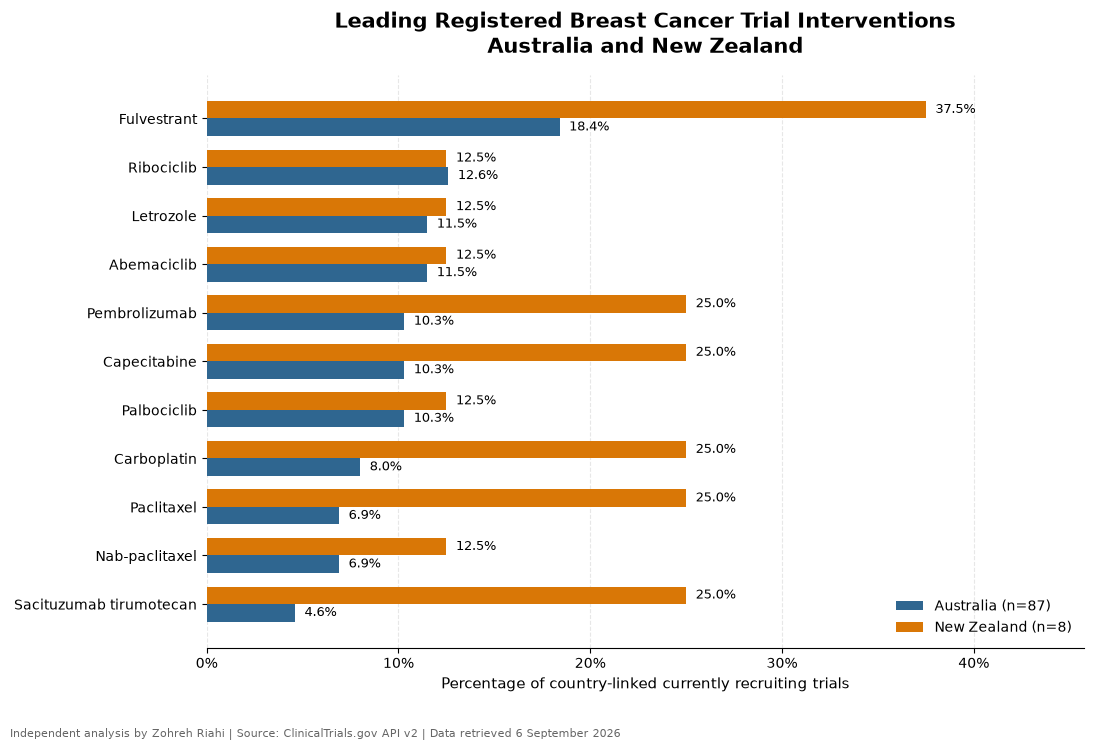

Figure 10 saved successfully:
Figure10_Intervention_Comparison_Australia_New_Zealand_2026-09-06.png


In [70]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# Remove generic supportive intervention label
table8_report = table8[
    table8["Intervention"].str.casefold() != "rescue medication"
].copy()

# Overwrite Table 8 with the report-ready version
table8_report.to_csv(
    "Table8_Top_Interventions_by_Country_2026-09-06.csv",
    index=False
)

print("Final Table 8 shape:", table8_report.shape)

# Sort for horizontal plotting
plot_data = (
    table8_report
    .sort_values(
        ["Australia_Percent", "New_Zealand_Percent"],
        ascending=[True, True]
    )
    .reset_index(drop=True)
)

y_positions = np.arange(len(plot_data))
bar_height = 0.36

fig, ax = plt.subplots(figsize=(11, 7.5))

australia_bars = ax.barh(
    y_positions - bar_height / 2,
    plot_data["Australia_Percent"],
    height=bar_height,
    color="#2F6690",
    label="Australia (n=87)"
)

new_zealand_bars = ax.barh(
    y_positions + bar_height / 2,
    plot_data["New_Zealand_Percent"],
    height=bar_height,
    color="#D97706",
    label="New Zealand (n=8)"
)

ax.set_yticks(y_positions)
ax.set_yticklabels(plot_data["Intervention"], fontsize=10)

ax.set_xlabel(
    "Percentage of country-linked currently recruiting trials",
    fontsize=11
)

ax.set_title(
    "Leading Registered Breast Cancer Trial Interventions\n"
    "Australia and New Zealand",
    fontsize=15,
    fontweight="bold",
    pad=16
)

ax.xaxis.set_major_formatter(
    FuncFormatter(lambda value, position: f"{value:.0f}%")
)

ax.xaxis.grid(
    True,
    linestyle="--",
    alpha=0.3
)

ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

ax.legend(
    loc="lower right",
    frameon=False,
    fontsize=10
)

maximum_percentage = max(
    plot_data["Australia_Percent"].max(),
    plot_data["New_Zealand_Percent"].max()
)

ax.set_xlim(0, maximum_percentage * 1.22)

# Add percentage labels
for bars in [australia_bars, new_zealand_bars]:

    for bar in bars:

        value = bar.get_width()

        if value > 0:
            ax.text(
                value + 0.5,
                bar.get_y() + bar.get_height() / 2,
                f"{value:.1f}%",
                va="center",
                fontsize=9
            )

fig.text(
    0.01,
    0.01,
    "Independent analysis by Zohreh Riahi | "
    "Source: ClinicalTrials.gov API v2 | "
    "Data retrieved 6 September 2026",
    fontsize=8,
    color="#666666"
)

plt.tight_layout(rect=[0, 0.05, 1, 1])

figure10_file = (
    "Figure10_Intervention_Comparison_"
    "Australia_New_Zealand_2026-09-06.png"
)

plt.savefig(
    figure10_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure 10 saved successfully:")
print(figure10_file)

In [71]:
# Create corrected combined intervention counts across 88 unique trials
combined_intervention_counts = (
    intervention_long
    .drop_duplicates(
        subset=["NCT_ID", "Intervention_Key"]
    )
    .groupby(["Intervention_Key", "Intervention"])
    ["NCT_ID"]
    .nunique()
    .reset_index(name="Trial_Count")
)

combined_intervention_counts["Percent_of_88_Trials"] = (
    combined_intervention_counts["Trial_Count"]
    / 88
    * 100
).round(1)

# Select the corrected top 10
corrected_table5 = (
    combined_intervention_counts
    .sort_values(
        ["Trial_Count", "Intervention"],
        ascending=[False, True]
    )
    .head(10)
    [["Intervention", "Trial_Count", "Percent_of_88_Trials"]]
    .reset_index(drop=True)
)

corrected_table5.insert(
    0,
    "Rank",
    range(1, len(corrected_table5) + 1)
)

# Replace the earlier table with the corrected version
corrected_table5_file = (
    "Table5_Top_10_Non_Placebo_Interventions_2026-09-06.csv"
)

corrected_table5.to_csv(
    corrected_table5_file,
    index=False
)

print("Corrected Table 5 saved successfully:")
print(corrected_table5_file)

display(corrected_table5)

Corrected Table 5 saved successfully:
Table5_Top_10_Non_Placebo_Interventions_2026-09-06.csv


,Rank,Intervention,Trial_Count,Percent_of_88_Trials
0,1,Fulvestrant,17,19.3
1,2,Ribociclib,11,12.5
2,3,Abemaciclib,10,11.4
3,4,Letrozole,10,11.4
4,5,Capecitabine,9,10.2
5,6,Palbociclib,9,10.2
6,7,Pembrolizumab,9,10.2
7,8,Carboplatin,7,8.0
8,9,Nab-paclitaxel,6,6.8
9,10,Paclitaxel,6,6.8


,Rank,Intervention,Trial_Count,Percent_of_88_Trials
0,1,Fulvestrant,17,19.3
1,2,Ribociclib,11,12.5
2,3,Abemaciclib,10,11.4
3,3,Letrozole,10,11.4
4,5,Capecitabine,9,10.2
5,5,Palbociclib,9,10.2
6,5,Pembrolizumab,9,10.2
7,8,Carboplatin,7,8.0
8,9,Nab-paclitaxel,6,6.8
9,9,Paclitaxel,6,6.8


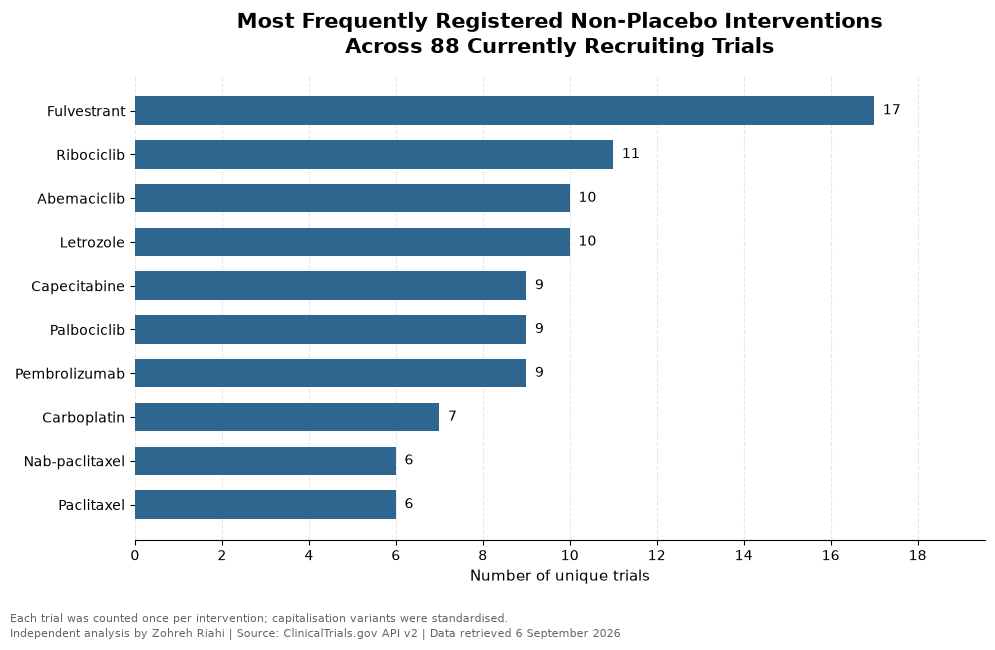

Corrected Figure 9 saved successfully:
Figure9_Most_Frequent_Non_Placebo_Interventions_2026-09-06.png


In [72]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# Assign equal ranks to interventions with equal counts
corrected_table5["Rank"] = (
    corrected_table5["Trial_Count"]
    .rank(method="min", ascending=False)
    .astype(int)
)

corrected_table5 = corrected_table5[
    [
        "Rank",
        "Intervention",
        "Trial_Count",
        "Percent_of_88_Trials"
    ]
]

# Save the final corrected Table 5
corrected_table5.to_csv(
    "Table5_Top_10_Non_Placebo_Interventions_2026-09-06.csv",
    index=False
)

display(corrected_table5)

# Prepare Figure 9
plot_table5 = corrected_table5.sort_values(
    ["Trial_Count", "Intervention"],
    ascending=[False, True]
).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 6.5))

bars = ax.barh(
    plot_table5["Intervention"],
    plot_table5["Trial_Count"],
    color="#2F6690",
    height=0.65
)

# Put the most frequent intervention at the top
ax.invert_yaxis()

ax.set_title(
    "Most Frequently Registered Non-Placebo Interventions\n"
    "Across 88 Currently Recruiting Trials",
    fontsize=15,
    fontweight="bold",
    pad=16
)

ax.set_xlabel(
    "Number of unique trials",
    fontsize=11
)

ax.xaxis.set_major_locator(
    MaxNLocator(integer=True)
)

ax.xaxis.grid(
    True,
    linestyle="--",
    alpha=0.3
)

ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

# Add trial-count labels
for bar in bars:

    value = int(bar.get_width())

    ax.text(
        value + 0.2,
        bar.get_y() + bar.get_height() / 2,
        str(value),
        va="center",
        fontsize=10
    )

ax.set_xlim(
    0,
    plot_table5["Trial_Count"].max() * 1.15
)

fig.text(
    0.01,
    0.035,
    "Each trial was counted once per intervention; "
    "capitalisation variants were standardised.",
    fontsize=8,
    color="#666666"
)

fig.text(
    0.01,
    0.012,
    "Independent analysis by Zohreh Riahi | "
    "Source: ClinicalTrials.gov API v2 | "
    "Data retrieved 6 September 2026",
    fontsize=8,
    color="#666666"
)

plt.tight_layout(rect=[0, 0.07, 1, 1])

figure9_file = (
    "Figure9_Most_Frequent_Non_Placebo_"
    "Interventions_2026-09-06.png"
)

plt.savefig(
    figure9_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Corrected Figure 9 saved successfully:")
print(figure9_file)

### Interpretation of the Intervention Landscape

After standardising differences in capitalisation, fulvestrant was the most frequently registered non-placebo intervention, appearing in 17 of the 88 unique currently recruiting trials (19.3%). Ribociclib appeared in 11 trials (12.5%), while abemaciclib and letrozole each appeared in 10 trials (11.4%). Capecitabine, palbociclib and pembrolizumab were each registered in nine trials (10.2%).

The country-level comparison showed that fulvestrant appeared in 16 of 87 Australia-linked trials (18.4%) and three of eight New Zealand-linked trials (37.5%). Capecitabine, carboplatin, paclitaxel, pembrolizumab and sacituzumab tirumotecan each appeared in two New Zealand-linked trials (25.0%).

These percentages should be interpreted cautiously because the New Zealand comparison is based on only eight trials, seven of which were also recruiting in Australia. A single New Zealand trial therefore represents 12.5 percentage points. Trials may also contain multiple interventions, and the registry does not consistently distinguish experimental treatments from comparator or background therapies.

In [73]:
import pandas as pd

site_file = (
    "Breast_Cancer_Currently_Recruiting_"
    "Sites_Aus_NZ_2026-09-06.csv"
)

sites = pd.read_csv(site_file)

print("Original site dataset:", sites.shape)

# Create one summary row for every city-region combination
city_map_data = (
    sites
    .groupby(
        ["Country", "State_Region", "City"],
        as_index=False
    )
    .agg(
        Site_Record_Count=("NCT_ID", "size"),
        Unique_Trial_Count=("NCT_ID", "nunique"),
        Facility_Label_Count=("Facility", "nunique"),
        Facilities=(
            "Facility",
            lambda values: " | ".join(
                sorted(set(values))
            )
        ),
        NCT_IDs=(
            "NCT_ID",
            lambda values: " | ".join(
                sorted(set(values))
            )
        )
    )
    .sort_values(
        [
            "Unique_Trial_Count",
            "Site_Record_Count",
            "Country",
            "City"
        ],
        ascending=[False, False, True, True]
    )
    .reset_index(drop=True)
)

map_data_file = (
    "MapData_City_Level_Recruiting_"
    "Trials_Aus_NZ_2026-09-06.csv"
)

city_map_data.to_csv(
    map_data_file,
    index=False
)

print("City-level map dataset:", city_map_data.shape)
print("Saved successfully:")
print(map_data_file)

display(
    city_map_data[
        [
            "Country",
            "State_Region",
            "City",
            "Site_Record_Count",
            "Unique_Trial_Count",
            "Facility_Label_Count"
        ]
    ].head(15)
)

Original site dataset: (377, 9)
City-level map dataset: (97, 8)
Saved successfully:
MapData_City_Level_Recruiting_Trials_Aus_NZ_2026-09-06.csv


,Country,State_Region,City,Site_Record_Count,Unique_Trial_Count,Facility_Label_Count
0,Australia,Victoria,Melbourne,38,33,19
1,Australia,South Australia,Adelaide,23,21,15
2,Australia,New South Wales,Darlinghurst,18,17,12
3,Australia,Western Australia,Nedlands,17,17,11
4,Australia,New South Wales,Sydney,23,15,21
5,Australia,New South Wales,Blacktown,12,12,5
6,Australia,Victoria,Clayton,12,12,8
7,Australia,New South Wales,Westmead,11,11,4
8,Australia,New South Wales,Camperdown,8,8,7
9,Australia,Victoria,Frankston,8,8,8


In [74]:
import re
import time
import unicodedata
import requests
import pandas as pd

from concurrent.futures import ThreadPoolExecutor, as_completed


def normalise_geographic_name(value, remove_region=False):

    if pd.isna(value):
        return ""

    text = unicodedata.normalize(
        "NFKD",
        str(value)
    ).encode(
        "ascii",
        "ignore"
    ).decode("ascii")

    text = text.casefold()
    text = text.replace("&", "and")
    text = re.sub(r"[^a-z0-9]+", " ", text)

    if remove_region:
        text = re.sub(r"\bregion\b", "", text)

    return " ".join(text.split())


def retrieve_study_locations(nct_id):

    url = (
        "https://clinicaltrials.gov/"
        f"api/v2/studies/{nct_id}"
    )

    for attempt in range(3):

        try:

            response = requests.get(
                url,
                timeout=30,
                headers={
                    "User-Agent":
                    "Breast-Cancer-Trial-Mapping-Project/1.0"
                }
            )

            if response.status_code == 429:
                time.sleep(3)
                continue

            response.raise_for_status()

            study_record = response.json()

            locations = (
                study_record
                .get("protocolSection", {})
                .get("contactsLocationsModule", {})
                .get("locations", [])
            )

            return nct_id, locations, None

        except Exception as error:

            if attempt == 2:
                return nct_id, [], str(error)

            time.sleep(2)


unique_nct_ids = sorted(
    sites["NCT_ID"].unique()
)

print(
    "Retrieving geographic locations for",
    len(unique_nct_ids),
    "studies..."
)

api_results = {}
api_errors = []

with ThreadPoolExecutor(max_workers=8) as executor:

    future_lookup = {
        executor.submit(
            retrieve_study_locations,
            nct_id
        ): nct_id
        for nct_id in unique_nct_ids
    }

    completed_count = 0

    for future in as_completed(future_lookup):

        nct_id, locations, error = future.result()

        api_results[nct_id] = locations

        if error:
            api_errors.append({
                "NCT_ID": nct_id,
                "Error": error
            })

        completed_count += 1

        if completed_count % 10 == 0:
            print(
                completed_count,
                "of",
                len(unique_nct_ids),
                "studies completed"
            )


# Extract all available AU/NZ geographic points
api_location_rows = []

for nct_id, locations in api_results.items():

    for location in locations:

        country = location.get("country", "")

        if country not in [
            "Australia",
            "New Zealand"
        ]:
            continue

        geo_point = location.get("geoPoint") or {}

        latitude = geo_point.get("lat")
        longitude = geo_point.get("lon")

        if latitude is None or longitude is None:
            continue

        api_location_rows.append({
            "NCT_ID": nct_id,
            "API_Facility": location.get(
                "facility",
                ""
            ),
            "API_City": location.get(
                "city",
                ""
            ),
            "API_State_Region": location.get(
                "state",
                ""
            ),
            "API_Country": country,
            "Latitude": latitude,
            "Longitude": longitude
        })


api_locations = pd.DataFrame(
    api_location_rows
)

print(
    "API locations with coordinates:",
    api_locations.shape
)


# Create standardised geographic matching columns
api_locations["City_Key"] = (
    api_locations["API_City"]
    .apply(normalise_geographic_name)
)

api_locations["State_Key"] = (
    api_locations["API_State_Region"]
    .apply(
        lambda value:
        normalise_geographic_name(
            value,
            remove_region=True
        )
    )
)

api_locations["Country_Key"] = (
    api_locations["API_Country"]
    .apply(normalise_geographic_name)
)


city_map_data["City_Key"] = (
    city_map_data["City"]
    .apply(normalise_geographic_name)
)

city_map_data["State_Key"] = (
    city_map_data["State_Region"]
    .apply(
        lambda value:
        normalise_geographic_name(
            value,
            remove_region=True
        )
    )
)

city_map_data["Country_Key"] = (
    city_map_data["Country"]
    .apply(normalise_geographic_name)
)


# Use the median coordinate when several trials
# provide coordinates for the same city
city_coordinate_reference = (
    api_locations
    .groupby(
        [
            "Country_Key",
            "State_Key",
            "City_Key"
        ],
        as_index=False
    )
    .agg(
        Latitude=("Latitude", "median"),
        Longitude=("Longitude", "median"),
        API_Coordinate_Records=(
            "NCT_ID",
            "size"
        )
    )
)


city_map_geo = city_map_data.merge(
    city_coordinate_reference,
    on=[
        "Country_Key",
        "State_Key",
        "City_Key"
    ],
    how="left"
)


coordinates_found = (
    city_map_geo["Latitude"]
    .notna()
    .sum()
)

print()
print(
    "Coordinates found:",
    coordinates_found,
    "of",
    len(city_map_geo)
)

print(
    "Coordinates still missing:",
    len(city_map_geo) - coordinates_found
)

print(
    "API request errors:",
    len(api_errors)
)


missing_coordinates = (
    city_map_geo[
        city_map_geo["Latitude"].isna()
    ][
        [
            "Country",
            "State_Region",
            "City",
            "Site_Record_Count",
            "Unique_Trial_Count"
        ]
    ]
    .sort_values(
        ["Country", "State_Region", "City"]
    )
    .reset_index(drop=True)
)

display(missing_coordinates)

Retrieving geographic locations for 88 studies...
10 of 88 studies completed
20 of 88 studies completed
30 of 88 studies completed
40 of 88 studies completed
50 of 88 studies completed
60 of 88 studies completed
70 of 88 studies completed
80 of 88 studies completed
API locations with coordinates: (424, 7)

Coordinates found: 85 of 97
Coordinates still missing: 12
API request errors: 0


,Country,State_Region,City,Site_Record_Count,Unique_Trial_Count
0,Australia,New South Wales,Macquarie University,4,4
1,Australia,New South Wales,Wollstonecraft,1,1
2,Australia,Queensland,Chermside,1,1
3,Australia,Queensland,Newcastle,1,1
4,Australia,Victoria,East Melbourne,2,2
5,Australia,Victoria,Fitzroy,1,1
6,Australia,Victoria,Melbourne N.,1,1
7,Australia,Victoria,Mount Waverly,1,1
8,Australia,Western Australia,Wembley,1,1
9,New Zealand,Bay of Plenty Region,Tauranga,1,1


In [75]:
# Preserve the original geographic fields
city_map_geo["Map_City"] = city_map_geo["City"]
city_map_geo["Map_State_Region"] = (
    city_map_geo["State_Region"]
)

city_map_geo["Coordinate_Source"] = ""

city_map_geo.loc[
    city_map_geo["Latitude"].notna(),
    "Coordinate_Source"
] = "ClinicalTrials.gov API v2"

city_map_geo["Location_QC_Note"] = ""


# Validated fallback coordinates for the 12 unmatched places
fallback_coordinates = {

    (
        "Australia",
        "New South Wales",
        "Macquarie University"
    ): {
        "Latitude": -33.7741970,
        "Longitude": 151.1127138,
        "Map_City": "Macquarie Park",
        "Map_State_Region": "New South Wales",
        "Note": (
            "Source location label refers to "
            "Macquarie University; mapped to its "
            "Macquarie Park location."
        )
    },

    (
        "Australia",
        "New South Wales",
        "Wollstonecraft"
    ): {
        "Latitude": -33.8332039,
        "Longitude": 151.1959273,
        "Map_City": "Wollstonecraft",
        "Map_State_Region": "New South Wales",
        "Note": ""
    },

    (
        "Australia",
        "Queensland",
        "Chermside"
    ): {
        "Latitude": -27.3849910,
        "Longitude": 153.0333220,
        "Map_City": "Chermside",
        "Map_State_Region": "Queensland",
        "Note": ""
    },

    (
        "Australia",
        "Queensland",
        "Newcastle"
    ): {
        "Latitude": -32.9004805,
        "Longitude": 151.7206504,
        "Map_City": "Newcastle",
        "Map_State_Region": "New South Wales",
        "Note": (
            "Registry source listed Queensland. "
            "The named facility, Calvary Mater "
            "Newcastle, is located in Waratah, "
            "New South Wales."
        )
    },

    (
        "Australia",
        "Victoria",
        "East Melbourne"
    ): {
        "Latitude": -37.8124980,
        "Longitude": 144.9858851,
        "Map_City": "East Melbourne",
        "Map_State_Region": "Victoria",
        "Note": ""
    },

    (
        "Australia",
        "Victoria",
        "Fitzroy"
    ): {
        "Latitude": -37.8010382,
        "Longitude": 144.9792611,
        "Map_City": "Fitzroy",
        "Map_State_Region": "Victoria",
        "Note": ""
    },

    (
        "Australia",
        "Victoria",
        "Melbourne N."
    ): {
        "Latitude": -37.8142454,
        "Longitude": 144.9631732,
        "Map_City": "Melbourne",
        "Map_State_Region": "Victoria",
        "Note": (
            "Abbreviated city label mapped to "
            "Melbourne."
        )
    },

    (
        "Australia",
        "Victoria",
        "Mount Waverly"
    ): {
        "Latitude": -37.8752637,
        "Longitude": 145.1281258,
        "Map_City": "Mount Waverley",
        "Map_State_Region": "Victoria",
        "Note": (
            "Map label uses the standard spelling "
            "Mount Waverley."
        )
    },

    (
        "Australia",
        "Western Australia",
        "Wembley"
    ): {
        "Latitude": -31.9336484,
        "Longitude": 115.8148091,
        "Map_City": "Wembley",
        "Map_State_Region": "Western Australia",
        "Note": ""
    },

    (
        "New Zealand",
        "Bay of Plenty Region",
        "Tauranga"
    ): {
        "Latitude": -37.6859006,
        "Longitude": 176.1675050,
        "Map_City": "Tauranga",
        "Map_State_Region": "Bay of Plenty Region",
        "Note": ""
    },

    (
        "New Zealand",
        "Canterbury Region",
        "Christchurch"
    ): {
        "Latitude": -43.5309550,
        "Longitude": 172.6364343,
        "Map_City": "Christchurch",
        "Map_State_Region": "Canterbury Region",
        "Note": ""
    },

    (
        "New Zealand",
        "Manawatū-Whanganui Region",
        "Palmerston North"
    ): {
        "Latitude": -40.3563170,
        "Longitude": 175.6112388,
        "Map_City": "Palmerston North",
        "Map_State_Region": (
            "Manawatū-Whanganui Region"
        ),
        "Note": ""
    }
}


# Add fallback coordinates without changing the raw fields
for location_key, coordinate_values in (
    fallback_coordinates.items()
):

    country, state_region, city = location_key

    location_mask = (
        (city_map_geo["Country"] == country)
        & (
            city_map_geo["State_Region"]
            == state_region
        )
        & (city_map_geo["City"] == city)
        & city_map_geo["Latitude"].isna()
    )

    matched_rows = location_mask.sum()

    if matched_rows != 1:
        print(
            "QC warning:",
            location_key,
            "matched",
            matched_rows,
            "rows"
        )

    city_map_geo.loc[
        location_mask,
        "Latitude"
    ] = coordinate_values["Latitude"]

    city_map_geo.loc[
        location_mask,
        "Longitude"
    ] = coordinate_values["Longitude"]

    city_map_geo.loc[
        location_mask,
        "Map_City"
    ] = coordinate_values["Map_City"]

    city_map_geo.loc[
        location_mask,
        "Map_State_Region"
    ] = coordinate_values["Map_State_Region"]

    city_map_geo.loc[
        location_mask,
        "Coordinate_Source"
    ] = "OpenStreetMap Nominatim fallback"

    city_map_geo.loc[
        location_mask,
        "Location_QC_Note"
    ] = coordinate_values["Note"]


# Final coordinate validation
remaining_missing = city_map_geo[
    city_map_geo[
        ["Latitude", "Longitude"]
    ].isna().any(axis=1)
]

print(
    "Coordinates complete:",
    len(city_map_geo) - len(remaining_missing),
    "of",
    len(city_map_geo)
)

print(
    "Remaining missing coordinates:",
    len(remaining_missing)
)

print(
    "ClinicalTrials.gov coordinates:",
    (
        city_map_geo["Coordinate_Source"]
        == "ClinicalTrials.gov API v2"
    ).sum()
)

print(
    "Fallback coordinates:",
    (
        city_map_geo["Coordinate_Source"]
        == "OpenStreetMap Nominatim fallback"
    ).sum()
)


# Save the complete geocoded map dataset
geocoded_map_file = (
    "MapData_City_Level_Recruiting_Trials_"
    "Aus_NZ_2026-09-06_Geocoded.csv"
)

city_map_geo.to_csv(
    geocoded_map_file,
    index=False
)

print("Saved successfully:")
print(geocoded_map_file)


# Display the 12 completed fallback locations
display(
    city_map_geo[
        city_map_geo["Coordinate_Source"]
        == "OpenStreetMap Nominatim fallback"
    ][
        [
            "Country",
            "State_Region",
            "City",
            "Map_State_Region",
            "Map_City",
            "Latitude",
            "Longitude",
            "Location_QC_Note"
        ]
    ].reset_index(drop=True)
)

Coordinates complete: 97 of 97
Remaining missing coordinates: 0
ClinicalTrials.gov coordinates: 85
Fallback coordinates: 12
Saved successfully:
MapData_City_Level_Recruiting_Trials_Aus_NZ_2026-09-06_Geocoded.csv


,Country,State_Region,City,Map_State_Region,Map_City,Latitude,Longitude,Location_QC_Note
0,Australia,New South Wales,Macquarie University,New South Wales,Macquarie Park,-33.774197,151.112714,Source location label refers to Macquarie Univ...
1,Australia,Victoria,East Melbourne,Victoria,East Melbourne,-37.812498,144.985885,
2,Australia,Queensland,Chermside,Queensland,Chermside,-27.384991,153.033322,
3,Australia,Victoria,Fitzroy,Victoria,Fitzroy,-37.801038,144.979261,
4,Australia,Victoria,Melbourne N.,Victoria,Melbourne,-37.814245,144.963173,Abbreviated city label mapped to Melbourne.
5,Australia,Victoria,Mount Waverly,Victoria,Mount Waverley,-37.875264,145.128126,Map label uses the standard spelling Mount Wav...
6,Australia,Queensland,Newcastle,New South Wales,Newcastle,-32.900481,151.720650,Registry source listed Queensland. The named f...
7,Australia,Western Australia,Wembley,Western Australia,Wembley,-31.933648,115.814809,
8,Australia,New South Wales,Wollstonecraft,New South Wales,Wollstonecraft,-33.833204,151.195927,
9,New Zealand,Canterbury Region,Christchurch,Canterbury Region,Christchurch,-43.530955,172.636434,


In [76]:
%pip install folium


   ---------------- ----------------------- 2/5 [jinja2]
   ---------------- ----------------------- 2/5 [jinja2]
   ---------------- ----------------------- 2/5 [jinja2]
   -------------------------------- ------- 4/5 [folium]
   -------------------------------- ------- 4/5 [folium]
   -------------------------------- ------- 4/5 [folium]
   ---------------------------------------- 5/5 [folium]

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [78]:
import pandas as pd
import folium
import math
import html

from folium.plugins import Fullscreen, MiniMap


# ---------------------------------------------------------
# Prepare the city-level map data
# ---------------------------------------------------------

map_data = city_map_geo.copy()


# Convert coordinates and counts to numeric values
numeric_columns = [
    "Latitude",
    "Longitude",
    "Unique_Trial_Count",
    "Site_Record_Count",
    "Facility_Label_Count"
]

for column in numeric_columns:

    map_data[column] = pd.to_numeric(
        map_data[column],
        errors="coerce"
    )


# Remove rows without usable coordinates
map_data = map_data.dropna(
    subset=["Latitude", "Longitude"]
).copy()


# Colours used for each country
country_colours = {
    "Australia": "#2F6F9F",
    "New Zealand": "#E07A00"
}


# ---------------------------------------------------------
# Helper function: split facility names and NCT identifiers
# ---------------------------------------------------------

def split_items(value):

    if pd.isna(value):
        return []

    text = str(value).strip()

    if not text:
        return []

    if " | " in text:
        items = text.split(" | ")
    else:
        items = text.split(";")

    clean_items = []
    seen = set()

    for item in items:

        item = item.strip()
        item_key = item.casefold()

        if item and item_key not in seen:

            clean_items.append(item)
            seen.add(item_key)

    return clean_items


# ---------------------------------------------------------
# Helper function: create facility list for popups
# ---------------------------------------------------------

def facility_list_html(value, limit=10):

    facilities = split_items(value)

    if not facilities:
        return "<em>Facility labels unavailable</em>"

    displayed = facilities[:limit]

    output = (
        "<ul style='"
        "padding-left:18px;"
        "margin:5px 0;"
        "'>"
    )

    for facility in displayed:

        output += (
            f"<li>{html.escape(facility)}</li>"
        )

    if len(facilities) > limit:

        additional_count = (
            len(facilities) - limit
        )

        output += (
            f"<li><em>and {additional_count} "
            "additional facility labels</em></li>"
        )

    output += "</ul>"

    return output


# ---------------------------------------------------------
# Helper function: create clickable ClinicalTrials.gov links
# ---------------------------------------------------------

def trial_links_html(value, limit=12):

    nct_ids = split_items(value)

    if not nct_ids:
        return "<em>NCT identifiers unavailable</em>"

    displayed = nct_ids[:limit]
    links = []

    for nct_id in displayed:

        safe_nct = html.escape(nct_id)

        link = (
            f"<a href='https://clinicaltrials.gov/study/{safe_nct}' "
            f"target='_blank'>{safe_nct}</a>"
        )

        links.append(link)

    output = ", ".join(links)

    if len(nct_ids) > limit:

        additional_count = (
            len(nct_ids) - limit
        )

        output += (
            f"<br><em>Plus {additional_count} "
            "additional trials</em>"
        )

    return output


# ---------------------------------------------------------
# Create the interactive map using OpenStreetMap
# ---------------------------------------------------------

trial_map = folium.Map(
    location=[
        map_data["Latitude"].mean(),
        map_data["Longitude"].mean()
    ],
    tiles="OpenStreetMap",
    zoom_start=4,
    control_scale=True
)


# ---------------------------------------------------------
# Create separate selectable layers for each country
# ---------------------------------------------------------

country_layers = {}

for country in [
    "Australia",
    "New Zealand"
]:

    country_layers[country] = (
        folium.FeatureGroup(
            name=country,
            show=True
        )
    )

    country_layers[country].add_to(
        trial_map
    )


# ---------------------------------------------------------
# Add one circle marker for every mapped city
# ---------------------------------------------------------

for _, row in map_data.iterrows():

    country = row["Country"]

    colour = country_colours.get(
        country,
        "#666666"
    )

    trial_count = int(
        row["Unique_Trial_Count"]
    )

    site_count = int(
        row["Site_Record_Count"]
    )

    facility_count = int(
        row["Facility_Label_Count"]
    )


    # Larger circles indicate more unique trials
    marker_radius = (
        5 + 2.1 * math.sqrt(trial_count)
    )


    # Prepare safe text for HTML popups
    city_label = html.escape(
        str(row["Map_City"])
    )

    region_label = html.escape(
        str(row["Map_State_Region"])
    )

    country_label = html.escape(
        str(country)
    )


    # Create facility and NCT sections
    facilities_html = facility_list_html(
        row.get("Facilities", "")
    )

    trials_html = trial_links_html(
        row.get("NCT_IDs", "")
    )


    coordinate_source = html.escape(
        str(
            row.get(
                "Coordinate_Source",
                ""
            )
        )
    )


    # Add a location quality-control note if one exists
    qc_note = row.get(
        "Location_QC_Note",
        ""
    )

    if (
        pd.isna(qc_note)
        or not str(qc_note).strip()
    ):

        qc_html = ""

    else:

        qc_html = (
            "<div style='"
            "margin-top:8px;"
            "padding:6px;"
            "background:#FFF4DC;"
            "border-left:3px solid #E07A00;"
            "'>"
            "<strong>Location note:</strong> "
            f"{html.escape(str(qc_note))}"
            "</div>"
        )


    # -----------------------------------------------------
    # Popup displayed after clicking a city marker
    # -----------------------------------------------------

    popup_html = f"""
    <div style="
        font-family:Arial, sans-serif;
        font-size:13px;
        line-height:1.4;
        width:370px;
    ">

        <div style="
            font-size:17px;
            font-weight:bold;
            color:{colour};
            margin-bottom:2px;
        ">
            {city_label}
        </div>

        <div style="
            color:#555555;
            margin-bottom:10px;
        ">
            {region_label}, {country_label}
        </div>

        <table style="
            width:100%;
            border-collapse:collapse;
            margin-bottom:10px;
        ">

            <tr>

                <td style="
                    padding:4px;
                    border-bottom:1px solid #DDDDDD;
                ">
                    Unique currently recruiting trials
                </td>

                <td style="
                    padding:4px;
                    border-bottom:1px solid #DDDDDD;
                    text-align:right;
                    font-weight:bold;
                ">
                    {trial_count}
                </td>

            </tr>

            <tr>

                <td style="
                    padding:4px;
                    border-bottom:1px solid #DDDDDD;
                ">
                    Site records
                </td>

                <td style="
                    padding:4px;
                    border-bottom:1px solid #DDDDDD;
                    text-align:right;
                ">
                    {site_count}
                </td>

            </tr>

            <tr>

                <td style="
                    padding:4px;
                    border-bottom:1px solid #DDDDDD;
                ">
                    Distinct facility labels
                </td>

                <td style="
                    padding:4px;
                    border-bottom:1px solid #DDDDDD;
                    text-align:right;
                ">
                    {facility_count}
                </td>

            </tr>

        </table>

        <strong>
            Registered facility labels
        </strong>

        {facilities_html}

        <div style="margin-top:10px;">

            <strong>
                ClinicalTrials.gov records
            </strong>

            <br>

            {trials_html}

        </div>

        {qc_html}

        <div style="
            margin-top:10px;
            color:#777777;
            font-size:11px;
        ">
            Coordinate source:
            {coordinate_source}
        </div>

    </div>
    """


    # -----------------------------------------------------
    # Tooltip displayed when hovering over the marker
    # -----------------------------------------------------

    tooltip_text = (
        f"{row['Map_City']}, "
        f"{row['Map_State_Region']} — "
        f"{trial_count} unique trial"
        f"{'s' if trial_count != 1 else ''}"
    )


    # -----------------------------------------------------
    # Add the city circle to its country layer
    # -----------------------------------------------------

    folium.CircleMarker(
        location=[
            row["Latitude"],
            row["Longitude"]
        ],
        radius=marker_radius,
        color=colour,
        weight=1.4,
        fill=True,
        fill_color=colour,
        fill_opacity=0.72,
        tooltip=folium.Tooltip(
            tooltip_text,
            sticky=True
        ),
        popup=folium.Popup(
            popup_html,
            max_width=430
        )
    ).add_to(
        country_layers[country]
    )


# ---------------------------------------------------------
# Fit the map around all 97 city locations
# ---------------------------------------------------------

trial_map.fit_bounds(
    [
        [
            map_data["Latitude"].min(),
            map_data["Longitude"].min()
        ],
        [
            map_data["Latitude"].max(),
            map_data["Longitude"].max()
        ]
    ],
    padding=(30, 30)
)


# ---------------------------------------------------------
# Add the map title
# ---------------------------------------------------------

title_html = """
<div style="
    position:fixed;
    top:10px;
    left:50%;
    transform:translateX(-50%);
    z-index:9999;
    background:rgba(255,255,255,0.94);
    border:1px solid #BBBBBB;
    border-radius:5px;
    padding:9px 18px;
    box-shadow:0 1px 5px rgba(0,0,0,0.25);
    text-align:center;
    font-family:Arial, sans-serif;
">

    <div style="
        font-size:17px;
        font-weight:bold;
    ">
        Currently Recruiting Breast Cancer Trials
    </div>

    <div style="
        font-size:13px;
        color:#555555;
    ">
        Registered city-level trial locations in
        Australia and New Zealand
    </div>

</div>
"""

trial_map.get_root().html.add_child(
    folium.Element(title_html)
)


# ---------------------------------------------------------
# Add the map legend
# ---------------------------------------------------------

legend_html = """
<div style="
    position:fixed;
    bottom:28px;
    left:28px;
    width:290px;
    z-index:9999;
    background:rgba(255,255,255,0.95);
    border:1px solid #BBBBBB;
    border-radius:5px;
    padding:10px 12px;
    box-shadow:0 1px 5px rgba(0,0,0,0.25);
    font-family:Arial, sans-serif;
    font-size:12px;
">

    <div style="
        font-weight:bold;
        margin-bottom:7px;
    ">
        Map legend
    </div>

    <div style="margin-bottom:5px;">

        <span style="
            display:inline-block;
            width:12px;
            height:12px;
            border-radius:50%;
            background:#2F6F9F;
            margin-right:6px;
        ">
        </span>

        Australia

    </div>

    <div style="margin-bottom:7px;">

        <span style="
            display:inline-block;
            width:12px;
            height:12px;
            border-radius:50%;
            background:#E07A00;
            margin-right:6px;
        ">
        </span>

        New Zealand

    </div>

    <div style="
        color:#555555;
    ">
        Circle size represents the number of unique
        currently recruiting trials linked to the city.
    </div>

    <div style="
        color:#777777;
        font-size:10px;
        margin-top:7px;
        border-top:1px solid #DDDDDD;
        padding-top:6px;
    ">
        Registered locations do not measure participant
        numbers, enrolment capacity or guaranteed access.
    </div>

</div>
"""

trial_map.get_root().html.add_child(
    folium.Element(legend_html)
)


# ---------------------------------------------------------
# Add interactive controls
# ---------------------------------------------------------

folium.LayerControl(
    position="topright",
    collapsed=False
).add_to(
    trial_map
)


Fullscreen(
    position="topleft",
    title="Full-screen map",
    title_cancel="Exit full-screen"
).add_to(
    trial_map
)


MiniMap(
    toggle_display=True,
    position="bottomright"
).add_to(
    trial_map
)


# ---------------------------------------------------------
# Save the corrected interactive HTML map
# ---------------------------------------------------------

interactive_map_file = (
    "Interactive_Map_Breast_Cancer_Recruiting_Trials_"
    "Australia_New_Zealand_2026-09-06.html"
)


trial_map.save(
    interactive_map_file
)


# ---------------------------------------------------------
# Print verification results
# ---------------------------------------------------------

print(
    "Map cities displayed:",
    len(map_data)
)

print(
    "Australia cities:",
    (
        map_data["Country"]
        == "Australia"
    ).sum()
)

print(
    "New Zealand cities:",
    (
        map_data["Country"]
        == "New Zealand"
    ).sum()
)

print(
    "Interactive map saved successfully:",
    interactive_map_file
)


# Display the interactive map inside the notebook
trial_map

Map cities displayed: 97
Australia cities: 90
New Zealand cities: 7
Interactive map saved successfully: Interactive_Map_Breast_Cancer_Recruiting_Trials_Australia_New_Zealand_2026-09-06.html


In [ ]:
trial_map.show_in_browser()

Your map should have been opened in your browser automatically.
Press ctrl+c to return.
